# Visualizing Wet-Lab Results (ELISA, qPCR, etc)

In [1]:
library(data.table)
library(ggplot2)
library(readxl)
library(ggpubr)
library(cowplot)

Warning message:
"package 'data.table' was built under R version 4.4.1"
Warning message:
"package 'ggplot2' was built under R version 4.4.1"
Warning message:
"package 'cowplot' was built under R version 4.4.1"

Adjuntando el paquete: 'cowplot'


The following object is masked from 'package:ggpubr':

    get_legend




## ELISA

In [71]:
elisa <- read_excel("../results/From_Arnav/ELISA_Summary.xlsx")
elisa[1:2,]

elisa$X <- paste0(elisa$Perturbation, "\n", elisa$Time)
elisa[elisa$Perturbation == "veh",]$X <- "Veh"
table(elisa$Date)
table(elisa$sm)
table(elisa[elisa$Date %in% c("1016", "1113"),]$sm)
table(elisa$X)

sm,Perturbation,Time,Samples,Dilution,Replicate,Date,Type,HYAL_ELISA
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
sm25,veh,NA,Sm25 veh - 1,100,1,1016,OG,236.6292
sm25,veh,NA,Sm25 veh - 2,100,2,1016,OG,316.2965



 725 1016 1113 
  40   40   40 


sm25 sm36 
  40   80 


sm25 sm36 
  40   40 


UPM\n3h UPM\n4h UPM\n6h UPM\n8h     Veh WSP\n3h WSP\n4h WSP\n6h WSP\n8h 
     16       8      16       8      24      16       8      16       8 

In [2]:
color_dict = c("WSP" = "coral", "Veh" = "grey", "UPM" = "black")

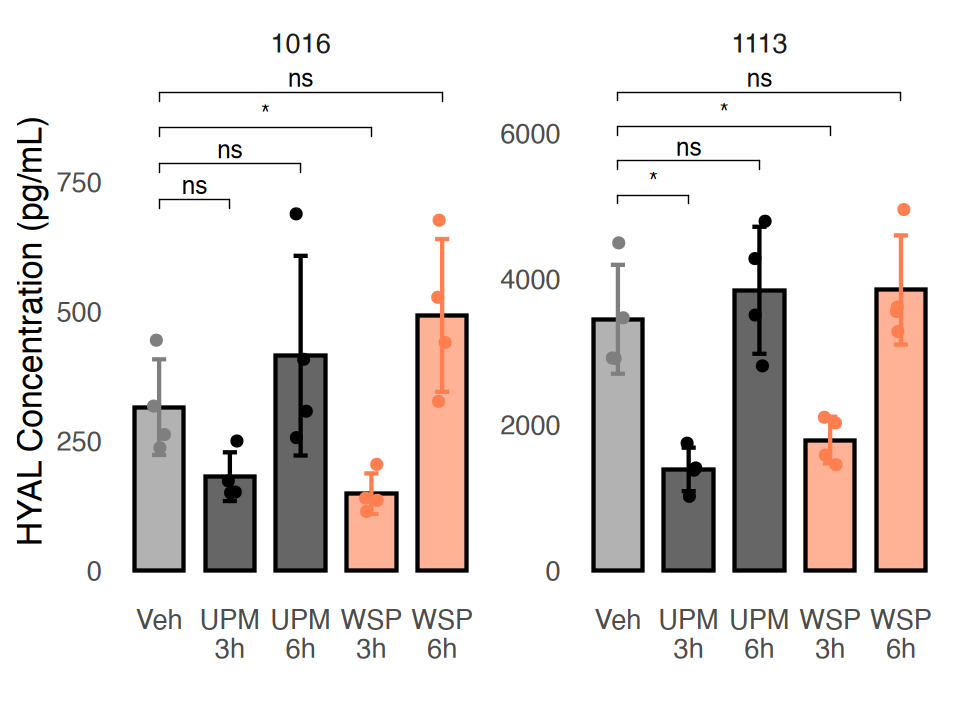

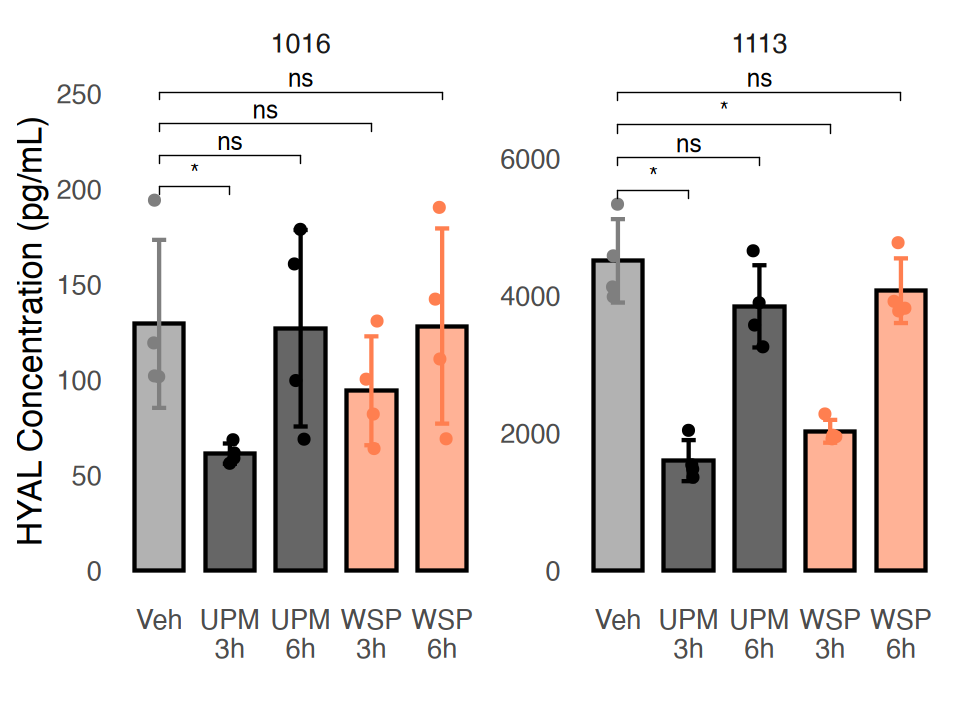

In [177]:
options(repr.plot.width=8, repr.plot.height=6)
ggplot(elisa[elisa$sm == "sm25" & elisa$Type == "OG",], 
aes(x=factor(X, levels=c("Veh", "UPM\n3h", "UPM\n6h", "WSP\n3h", "WSP\n6h")), y=HYAL_ELISA, color=Perturbation, fill=Perturbation) ) + 
  # Bar plot of means
  stat_summary(
    fun = "mean",
    geom = "col",
    alpha = 0.6,
    color = "black", width=0.7
  ) +
  # Standard deviation error bars
  stat_summary(
    fun.data = mean_sdl,
    fun.args = list(mult = 1),
    geom = "errorbar",
    width = 0.2
  ) + facet_wrap(~Date, scales="free") +
  # Individual data points
  geom_point(position = position_jitter(width = 0.1), size = 2) +
  # Significance brackets (example comparisons)
  stat_compare_means(
	aes(group = Date),
    method = "wilcox.test",
    comparisons = list(
      c("Veh", "UPM\n3h"),
      c("Veh", "UPM\n6h"),
      c("Veh", "WSP\n3h"),
      c("Veh", "WSP\n6h")
    ),
    label = "p.signif",   # prints **, ***, ns, etc.
	size=5
  ) +
  theme_minimal(base_size=20) +
  scale_color_manual(values = color_dict) +
  scale_fill_manual(values = color_dict) +
  labs(
    x = "",
    y = "HYAL Concentration (pg/mL)"
  ) +
  theme(legend.position = "none", panel.grid.major = element_blank(), # Removes major grid lines
  panel.grid.minor = element_blank())  
ggsave("./plots/ELISA_sm25.pdf", width=8, height=6)

  
  ggplot(elisa[elisa$sm == "sm36" & elisa$Type == "OG",], 
aes(x=factor(X, levels=c("Veh", "UPM\n3h", "UPM\n6h", "WSP\n3h", "WSP\n6h")), y=HYAL_ELISA, color=Perturbation, fill=Perturbation) ) + 
  # Bar plot of means
  stat_summary(
    fun = "mean",
    geom = "col",
    alpha = 0.6,
    color = "black", width=0.7
  ) +
  # Standard deviation error bars
  stat_summary(
    fun.data = mean_sdl,
    fun.args = list(mult = 1),
    geom = "errorbar",
    width = 0.2
  ) + facet_wrap(~Date, scales="free") +
  # Individual data points
  geom_point(position = position_jitter(width = 0.1), size = 2) +
  # Significance brackets (example comparisons)
  stat_compare_means(
	aes(group = Date),
    method = "wilcox.test",
    comparisons = list(
      c("Veh", "UPM\n3h"),
      c("Veh", "UPM\n6h"),
      c("Veh", "WSP\n3h"),
      c("Veh", "WSP\n6h")
    ),
    label = "p.signif",   # prints **, ***, ns, etc.
	size=5
  ) +
  theme_minimal(base_size=20) +
  scale_color_manual(values = color_dict) +
  scale_fill_manual(values = color_dict) +
  labs(
    x = "",
    y = "HYAL Concentration (pg/mL)"
  ) +
  theme(legend.position = "none", panel.grid.major = element_blank(), # Removes major grid lines
  panel.grid.minor = element_blank())  

ggsave("./plots/ELISA_sm36.pdf", width=8, height=6)


Saving 7 x 7 in image


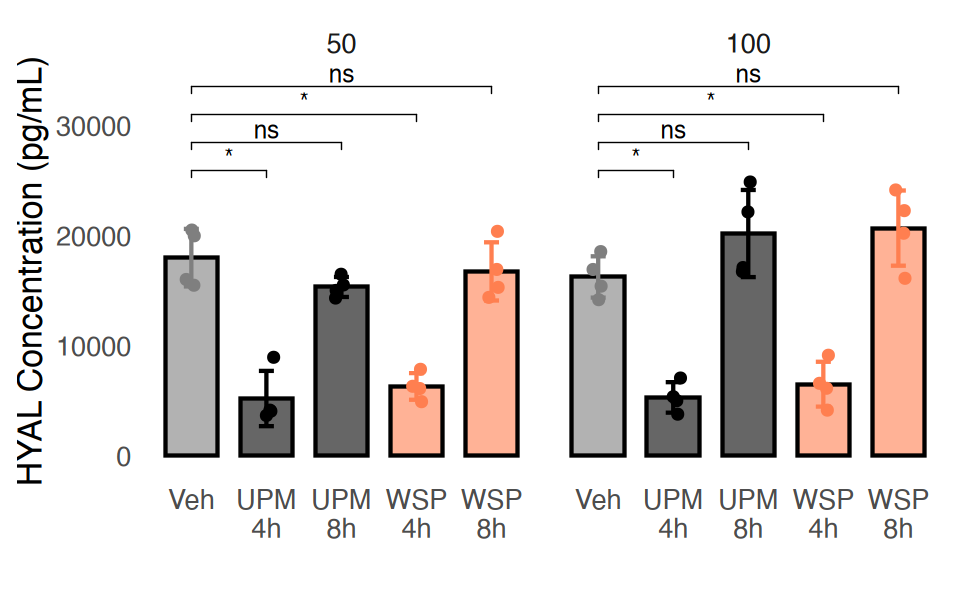

In [175]:
options(repr.plot.width=8, repr.plot.height=5)
ggplot(elisa[elisa$sm == "sm36" & elisa$Type == "submerged",], 
aes(x=factor(X, levels=c("Veh", "UPM\n4h", "UPM\n8h", "WSP\n4h", "WSP\n8h")), y=HYAL_ELISA, color=Perturbation, fill=Perturbation) ) + 
  # Bar plot of means
  stat_summary(
    fun = "mean",
    geom = "col",
    alpha = 0.6,
    color = "black", width=0.7
  ) + facet_wrap(~Dilution) +
  # Standard deviation error bars
  stat_summary(
    fun.data = mean_sdl,
    fun.args = list(mult = 1),
    geom = "errorbar",
    width = 0.2
  ) +
  # Individual data points
  geom_point(position = position_jitter(width = 0.1), size = 2) +
  # Significance brackets (example comparisons)
  stat_compare_means(
    method = "wilcox.test",
    comparisons = list(
      c("Veh", "UPM\n4h"),
      c("Veh", "UPM\n8h"),
      c("Veh", "WSP\n4h"),
      c("Veh", "WSP\n8h")
    ),
    label = "p.signif",   # prints **, ***, ns, etc.
	size=5
  ) +
  theme_minimal(base_size=20) +
  scale_color_manual(values = color_dict) +
  scale_fill_manual(values = color_dict) +
  labs(
    x = "",
    y = "HYAL Concentration (pg/mL)"
  ) +
  theme(legend.position = "none", panel.grid.major = element_blank(), # Removes major grid lines
  panel.grid.minor = element_blank()) 

ggsave("./plots/ELISA_sm36_submerged.pdf")

## qPCR

### TOMM7/IL6 enhancer

In [2]:
library(dplyr)
library(stringr)
library(tidyr)
get_veh_subtracted_df_b2b <- function(df) {
	# Identify normalized gene columns
gene_cols <- grep("_norm$", names(df), value = TRUE)

df2 <- df %>%
  # Compute average Vehicle value per Strain
  left_join(
    df %>%
      filter(Perturbation == "Veh") %>%
      group_by(Strain) %>%
      summarise(
        across(
          all_of(gene_cols),
          ~ median(.x, na.rm = TRUE),
          .names = "{.col}_veh_mean"
        ),
        .groups = "drop"
      ),
    by = "Strain"
  ) %>%
  
  # Subtract mean Veh value per Strain
  mutate(
    across(
      all_of(gene_cols),
      ~ .x - get(paste0(cur_column(), "_veh_mean")),
      .names = "{.col}_adj"
    )
  ) %>%
  
  # Optional cleanup of the temporary mean columns
  select(`Sample Name`, X, Strain, ends_with("_norm_adj")) 
  # Get the long version for plotting
  # Identify adjusted gene columns
adj_cols <- grep("_norm_adj$", names(df2), value = TRUE)

df_long <- df2 %>%
  pivot_longer(
    cols = all_of(adj_cols),
    names_to = "gene",
    values_to = "value"
  ) %>%
  mutate(
    gene = sub("_norm_adj$", "", gene)  # clean gene names for plotting
  )
}


Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'stringr' was built under R version 4.4.1"
Warning message:
"package 'tidyr' was built under R version 4.4.1"


In [4]:
qpcr <- read_excel("../results/Wet_Lab/TOMM7_IL6_qPCR.xlsx")
qpcr[1:2,]

qpcr$X <- paste0(qpcr$Perturbation, "\n", qpcr$Time)
qpcr[qpcr$Perturbation == "Veh",]$X <- "Veh"
table(qpcr$Date)

Sample Name,CT,Perturbation,Time,Date,Strain,RPL19,CYP1A1,TOMM7,IL6,TOMM7a,TOMM7b,CYP1A1_norm,TOMM7_norm,IL6_norm,TOMM7a_norm,TOMM7b_norm
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NC_v1,B2B,Veh,NA,3.6.26,Cas9-NC,20.64697,29.99940,25.49494,32.96704,NA,NA,9.352428,4.847971,12.32007,NA,NA
NC_v2,B2B,Veh,NA,3.6.26,Cas9-NC,20.65795,30.32172,25.99330,33.98367,NA,NA,9.663767,5.335342,13.32572,NA,NA



2.27.26 3.18.26  3.6.26 
     16      24      24 

In [5]:
qpcr_plot= get_veh_subtracted_df_b2b(qpcr[qpcr$Date == "2.27.26",])
qpcr_plot$Date <- "2.27.26"
qpcr_plot2 = get_veh_subtracted_df_b2b(qpcr[qpcr$Date == "3.6.26",])
qpcr_plot2$Date <- "3.6.26"
qpcr_plot <- rbind(qpcr_plot, qpcr_plot2)
qpcr_plot2 = get_veh_subtracted_df_b2b(qpcr[qpcr$Date == "3.18.26",])
qpcr_plot2$Date <- "3.18.26"
qpcr_plot <- rbind(qpcr_plot, qpcr_plot2)

In [6]:
table(qpcr_plot$X)
table(qpcr_plot$Strain)
table(qpcr_plot$Date)
color_spec_dict = c("Cas9-NC" = "grey60", "Cas9-Enh" = "blue")


    Veh WSP\n2h WSP\n4h 
    120     120      80 


Cas9-Enh  Cas9-NC 
     160      160 


2.27.26 3.18.26  3.6.26 
     80     120     120 

### Linear model

In [174]:
filt_plot = qpcr_plot[qpcr_plot$Date !="2.27.26" & qpcr_plot$X == "WSP\n4h",]
filt_plot = filt_plot[!is.na(filt_plot$value),]
filt_plot$Strain <- relevel(factor(filt_plot$Strain), ref = "Cas9-NC") 
filt_plot <- as.data.table(filt_plot)
filt_plot[1:2,]

Sample Name,X,Strain,gene,value,Date
<chr>,<chr>,<fct>,<chr>,<dbl>,<chr>
NC_W4_1,WSP 4h,Cas9-NC,CYP1A1,-4.1772413,3.6.26
NC_W4_1,WSP 4h,Cas9-NC,TOMM7,-0.1887646,3.6.26


In [175]:
tom_fit = lm(data=as.data.frame(filt_plot[filt_plot$gene == "TOMM7"]), value ~ Strain*Date)
summary(tom_fit)

il6_fit = lm(data=as.data.frame(filt_plot[filt_plot$gene == "IL6"]), value ~ Strain*Date)
summary(il6_fit)

cyp_fit = lm(data=as.data.frame(filt_plot[filt_plot$gene == "CYP1A1"]), value ~ Strain*Date)



Call:
lm(formula = value ~ Strain * Date, data = as.data.frame(filt_plot[filt_plot$gene == 
    "TOMM7"]))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.60808 -0.13132 -0.01747  0.16064  0.47879 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 0.1238     0.1593   0.777 0.452084    
StrainCas9-Enh             -0.9516     0.2252  -4.225 0.001179 ** 
Date3.6.26                 -0.6766     0.2252  -3.004 0.010988 *  
StrainCas9-Enh:Date3.6.26   1.7533     0.3185   5.504 0.000135 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3185 on 12 degrees of freedom
Multiple R-squared:  0.7279,	Adjusted R-squared:  0.6599 
F-statistic:  10.7 on 3 and 12 DF,  p-value: 0.001042



Call:
lm(formula = value ~ Strain * Date, data = as.data.frame(filt_plot[filt_plot$gene == 
    "IL6"]))

Residuals:
    Min      1Q  Median      3Q     Max 
-0.5758 -0.3284 -0.2118  0.3281  1.3739 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)                -0.5565     0.2867  -1.941 0.076159 .  
StrainCas9-Enh             -0.3179     0.4055  -0.784 0.448251    
Date3.6.26                 -2.2079     0.4055  -5.445 0.000149 ***
StrainCas9-Enh:Date3.6.26   1.9975     0.5735   3.483 0.004519 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.5735 on 12 degrees of freedom
Multiple R-squared:  0.7476,	Adjusted R-squared:  0.6846 
F-statistic: 11.85 on 3 and 12 DF,  p-value: 0.0006703


In [176]:
summary(cyp_fit)$coefficients["StrainCas9-NC",4]
summary(cyp_fit)$coefficients["StrainCas9-NC","Estimate"]
summary(cyp_fit)$coefficients["StrainCas9-NC","Std. Error"]

ERROR: Error in summary(cyp_fit)$coefficients["StrainCas9-NC", 4]: sub'indice fuera de  los l'imites


In [177]:
res <- filt_plot[
  ,
  {
    fit <- lm(value ~ Strain*Date)
    
    .(
      p_value = summary(fit)$coefficients["StrainCas9-Enh",4],
      effect = summary(fit)$coefficients["StrainCas9-Enh","Estimate"], 
	  std_error = summary(fit)$coefficients["StrainCas9-Enh","Std. Error"],
	  p_value_mix = summary(fit)$coefficients["StrainCas9-Enh:Date3.6.26",4],
      effect_mix = summary(fit)$coefficients["StrainCas9-Enh:Date3.6.26","Estimate"], 
	  std_error_mix = summary(fit)$coefficients["StrainCas9-Enh:Date3.6.26","Std. Error"]
    )
  },
  by = gene
][
  , p_adj := p.adjust(p_value, method = "BH")
][
  , p_adj_mix := p.adjust(p_value_mix, method = "BH")
]

res <- as.data.frame(res)
res <- res %>% add_significance("p_adj", cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 0.1, 1),
       symbols = c("****", "***", "**", "*", ".", "ns")) %>%
	   add_significance("p_adj_mix", cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 0.1, 1),
       symbols = c("****", "***", "**", "*", ".", "ns"))



In [178]:
res

gene,p_value,effect,std_error,p_value_mix,effect_mix,std_error_mix,p_adj,p_adj_mix,p_adj.signif,p_adj_mix.signif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CYP1A1,0.101155890,0.5415487,0.3050093,0.4109850230,-0.3674364,0.4313483,0.151733835,0.4109850230,ns,ns
TOMM7,0.001178603,-0.9515843,0.2252322,0.0001352798,1.7533236,0.3185265,0.003535809,0.0004058393,**,***
IL6,0.448251024,-0.3179088,0.4055065,0.0045192692,1.9975452,0.5734728,0.448251024,0.0067789038,ns,**


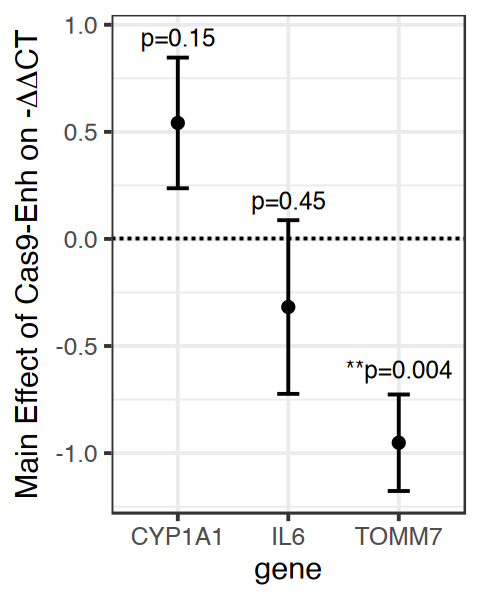

In [202]:
res$y.position <- c(0.94, -0.61, 0.18)
res$p_label <- c("p=0.15", "**p=0.004", "p=0.45")
ggplot(res, aes(x = gene, y = effect)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_point() +
  geom_errorbar(aes(ymin = effect - std_error, ymax = effect + std_error), width = 0.2) +
  theme_bw(base_size=18) + labs(y=expression("Main Effect of Cas9-Enh on -"*Delta*Delta*"CT"))  + 
  geom_text(data = res, aes(x = gene, y = y.position, label = p_label), 
             size = 5)
#expression("-"*Delta*Delta*"CT (Vehicle = 0)")


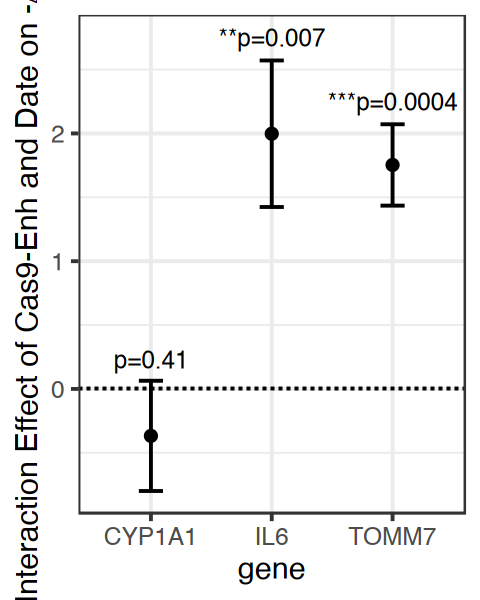

In [203]:
res$y.position <- c(0.23, 2.25, 2.75)
res$p_label <- c("p=0.41", "***p=0.0004", "**p=0.007")
ggplot(res, aes(x = gene, y = effect_mix)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_point() +
  geom_errorbar(aes(ymin = effect_mix - std_error_mix, ymax = effect_mix + std_error_mix), width = 0.2) +
  theme_bw(base_size=18) + labs(y=expression("Interaction Effect of Cas9-Enh and Date on -"*Delta*Delta*"CT"))  + 
  geom_text(data = res, aes(x = gene, y = y.position, label = p_label), 
             size = 5)


In [144]:
res

gene,p_value,effect,std_error,p_value_mix,effect_mix,std_error_mix,p_adj,p_adj_mix
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CYP1A1,0.101155890,-0.5415487,0.3050093,0.4109850230,0.3674364,0.4313483,0.151733835,0.4109850230
TOMM7,0.001178603,0.9515843,0.2252322,0.0001352798,-1.7533236,0.3185265,0.003535809,0.0004058393
IL6,0.448251024,0.3179088,0.4055065,0.0045192692,-1.9975452,0.5734728,0.448251024,0.0067789038


### Differences

In [100]:
qpcr_plot[1:2,]

filt_plot = qpcr_plot[qpcr_plot$Date !="2.27.26" & qpcr_plot$X == "WSP\n4h",]
filt_plot = filt_plot[!is.na(filt_plot$value),]
filt_plot$rep <- str_replace(str_split_fixed(filt_plot[["Sample Name"]], "_", 3)[,3], "v", "")
filt_plot <- as.data.table(filt_plot)
filt_plot[1:4,]
unique(filt_plot$Strain)

# for each gene (column gene) and date (column Date)
# get the Cas9-NC - Cas9-Enh (column Strain) value (column value) (for each rep (column rep))


diff_df <- dcast(
  filt_plot,
  gene + Date + rep ~ Strain,
  value.var = "value"
)[
  , diff := `Cas9-NC` - `Cas9-Enh`
]
diff_df$abs_diff <- abs(diff_df$diff)
dim(diff_df)

Sample Name,X,Strain,gene,value,Date
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
NC_v1,Veh,Cas9-NC,CYP1A1,0.01916027,2.27.26
NC_v1,Veh,Cas9-NC,TOMM7,NA,2.27.26


Sample Name,X,Strain,gene,value,Date,rep
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
NC_W4_1,WSP 4h,Cas9-NC,CYP1A1,-4.1772413,3.6.26,1
NC_W4_1,WSP 4h,Cas9-NC,TOMM7,-0.1887646,3.6.26,1
NC_W4_1,WSP 4h,Cas9-NC,IL6,-1.3904715,3.6.26,1
NC_W4_2,WSP 4h,Cas9-NC,CYP1A1,-4.7994757,3.6.26,2


[1] "Cas9-NC"  "Cas9-Enh"

[1] 24  7

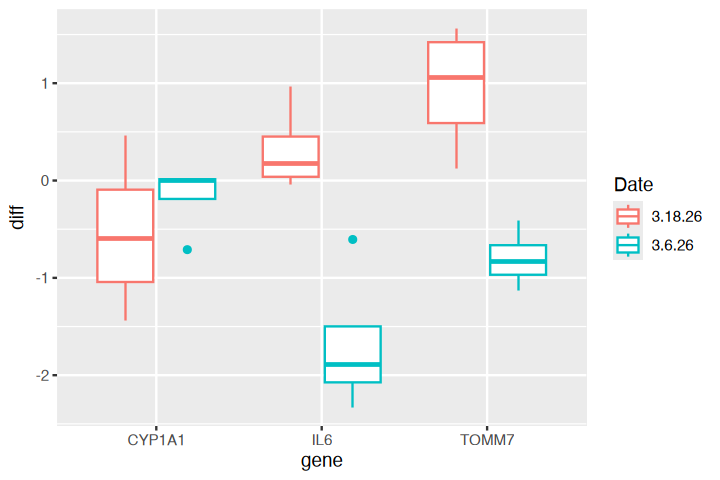

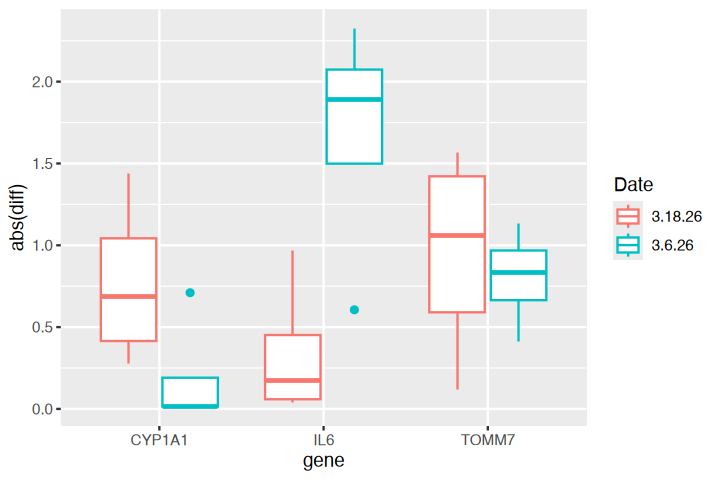

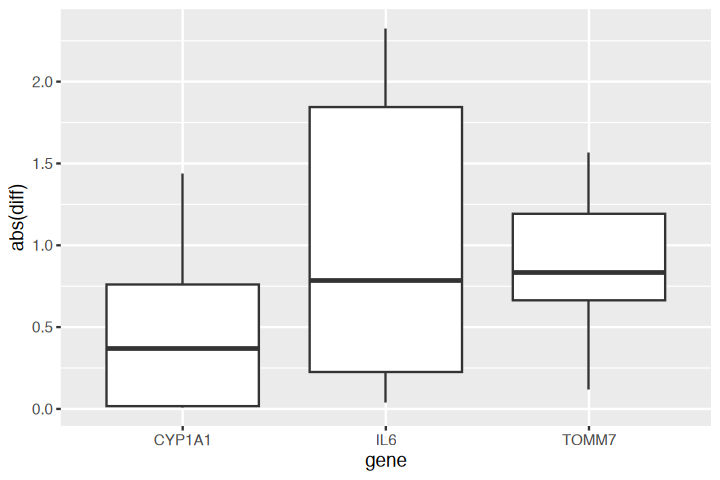

In [ ]:
ggplot(diff_df, aes(x=gene, y=diff, color=Date)) + geom_boxplot()

ggplot(diff_df, aes(x=gene, y=abs(diff), color=Date)) + geom_boxplot()



In [101]:
diff_df[
  ,
  .(
    n = .N,
    unique_vals = uniqueN(abs_diff),
    min = min(abs_diff, na.rm = TRUE),
    max = max(abs_diff, na.rm = TRUE),
    median = median(abs_diff, na.rm = TRUE),
	mean = mean(abs_diff, na.rm = TRUE)
  ),
  by = gene
]

gene,n,unique_vals,min,max,median,mean
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
CYP1A1,8,8,0.01162815,1.436730,0.3696337,0.4802701
IL6,8,8,0.04138184,2.327245,0.7871633,1.0091181
TOMM7,8,8,0.11953735,1.566372,0.8308487,0.8766618


### Usual

In [20]:
# do all pairwise comparisons within each gene
library(dplyr)
library(rstatix)

stat_2_df <- qpcr_plot[qpcr_plot$Date == "2.27.26" & !is.na(qpcr_plot$value),] %>%
  filter(X != "Veh") %>%
  group_by(gene, X) %>%                     # WITHIN each gene and condition
  wilcox_test(value ~ Strain) %>%           # non-parametric test
  adjust_pvalue(method = "BH") %>%          # optional, but recommended
  add_significance("p", cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 0.1, 1),
       symbols = c("****", "***", "**", "*", ".", "ns")) %>%
  ungroup()
stat_2_df


stat_36_df <- qpcr_plot[qpcr_plot$Date == "3.6.26" & !is.na(qpcr_plot$value),] %>%
  filter(X != "Veh") %>%
  group_by(gene, X) %>%                     # WITHIN each gene and condition
  wilcox_test(value ~ Strain) %>%           # non-parametric test
  adjust_pvalue(method = "BH") %>%          # optional, but recommended
  add_significance("p", cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 0.1, 1),
       symbols = c("****", "***", "**", "*", ".", "ns")) %>%
  ungroup()
stat_36_df

stat_318_df <- qpcr_plot[qpcr_plot$Date == "3.18.26" & !is.na(qpcr_plot$value),] %>%
  filter(X != "Veh") %>%
  group_by(gene, X) %>%                     # WITHIN each gene and condition
  wilcox_test(value ~ Strain) %>%           # non-parametric test
  adjust_pvalue(method = "BH") %>%          # optional, but recommended
  add_significance("p", cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 0.1, 1),
       symbols = c("****", "***", "**", "*", ".", "ns")) %>%
  ungroup()
stat_318_df

X,gene,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.signif
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
WSP 2h,CYP1A1,value,Cas9-Enh,Cas9-NC,4,4,1,0.0571,0.1142,.
WSP 2h,IL6,value,Cas9-Enh,Cas9-NC,4,4,3,0.2000,0.2000,ns
WSP 2h,TOMM7a,value,Cas9-Enh,Cas9-NC,4,4,2,0.1140,0.1520,ns
WSP 2h,TOMM7b,value,Cas9-Enh,Cas9-NC,4,4,1,0.0571,0.1142,.


X,gene,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.signif
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
WSP 2h,CYP1A1,value,Cas9-Enh,Cas9-NC,4,4,7,0.8860,0.8860,ns
WSP 4h,CYP1A1,value,Cas9-Enh,Cas9-NC,4,4,11,0.4860,0.7290,ns
WSP 2h,IL6,value,Cas9-Enh,Cas9-NC,4,4,9,0.8860,0.8860,ns
WSP 4h,IL6,value,Cas9-Enh,Cas9-NC,4,4,16,0.0286,0.0858,*
WSP 2h,TOMM7,value,Cas9-Enh,Cas9-NC,3,4,3,0.4000,0.7290,ns
WSP 4h,TOMM7,value,Cas9-Enh,Cas9-NC,4,4,16,0.0286,0.0858,*


X,gene,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.signif
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
WSP 2h,CYP1A1,value,Cas9-Enh,Cas9-NC,4,4,0,0.0286,0.0858,*
WSP 4h,CYP1A1,value,Cas9-Enh,Cas9-NC,4,4,13,0.2000,0.2400,ns
WSP 2h,IL6,value,Cas9-Enh,Cas9-NC,4,4,3,0.2000,0.2400,ns
WSP 4h,IL6,value,Cas9-Enh,Cas9-NC,4,4,5,0.4860,0.4860,ns
WSP 2h,TOMM7,value,Cas9-Enh,Cas9-NC,4,4,0,0.0286,0.0858,*
WSP 4h,TOMM7,value,Cas9-Enh,Cas9-NC,4,4,1,0.0571,0.1142,.


In [26]:
plot_function <- function(qpcr_plot_use, stat_df_use) {
	# add y positions for plotting
	stat_df_use <- stat_df_use %>%
	filter(p < 0.1) %>%
	group_by(gene) %>%
	mutate(y.position = max(qpcr_plot_use$value, na.rm = TRUE) + 1) %>%
	ungroup()
	print(stat_df_use)

	ggplot(qpcr_plot_use,
aes(x=X, y=-value, color=factor(Strain, levels=c("Cas9-NC", "Cas9-Enh")))) + 
geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
facet_wrap(~gene, nrow=1) +
  #geom_jitter(width=0.1, size=2) +
  stat_pvalue_manual(
    stat_df_use,
    label = "p",   # or "p" if you want exact values
    tip.length = 0.01,
    hide.ns = TRUE
  ) +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"), color="") 
}

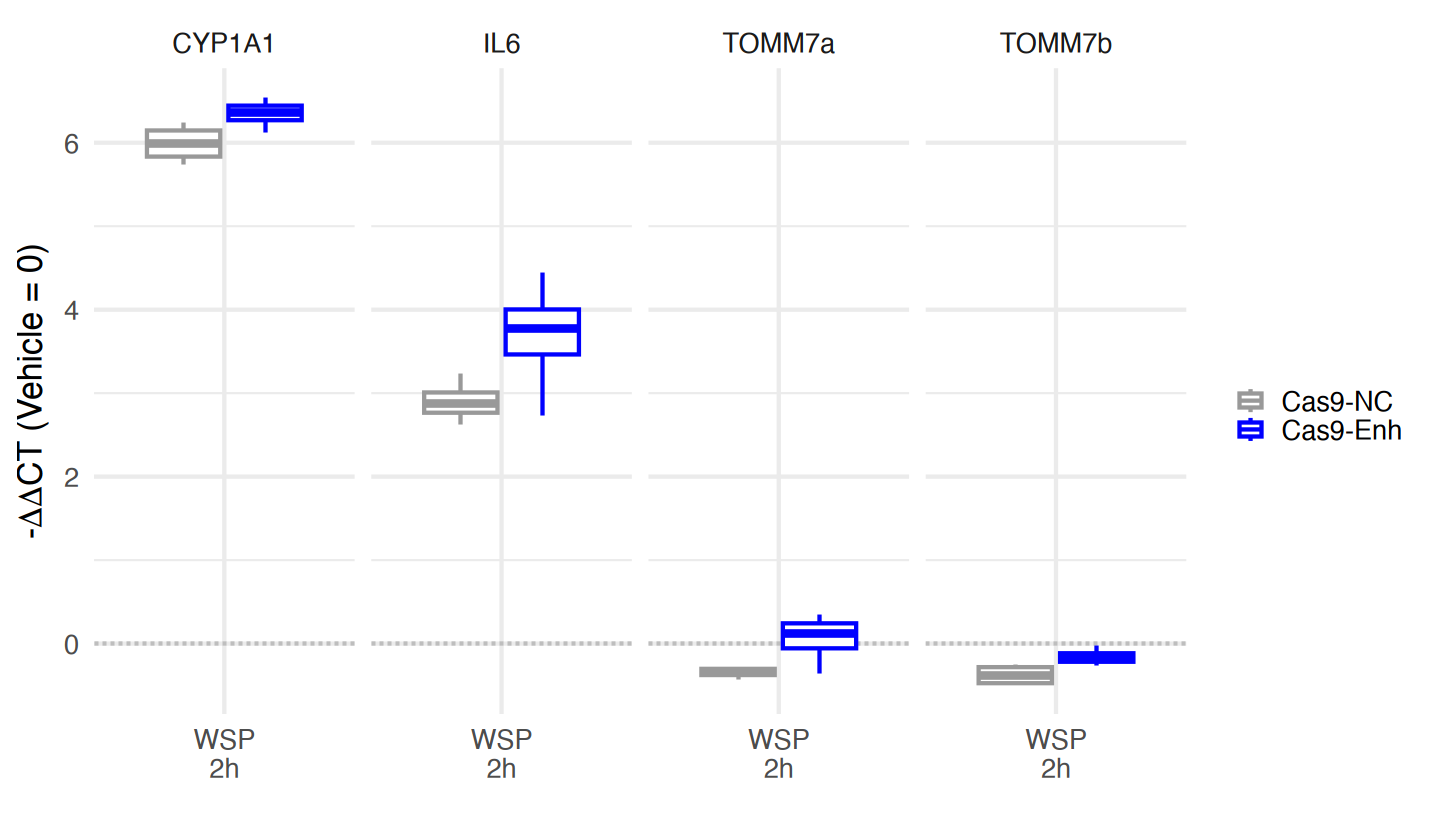

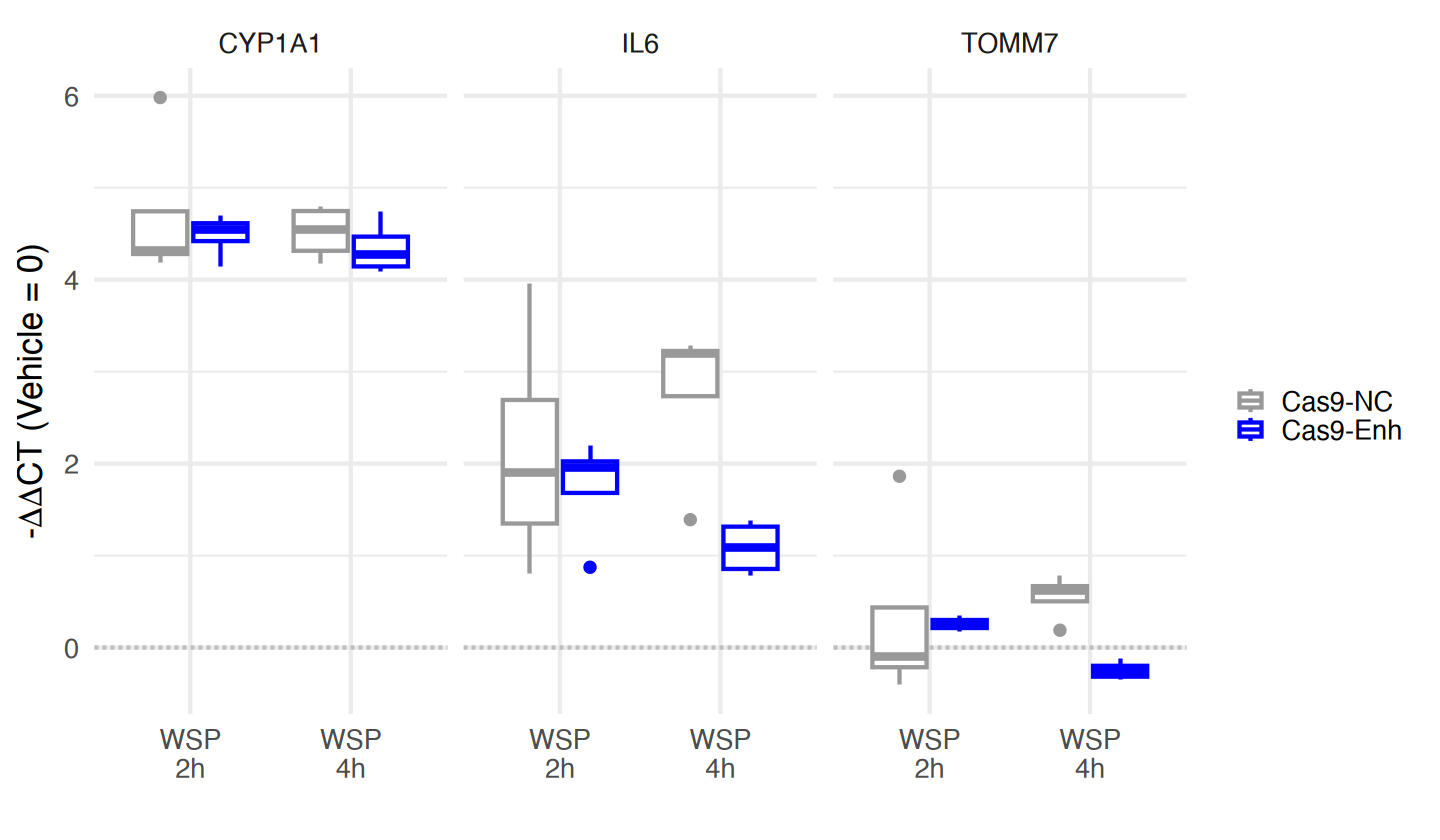

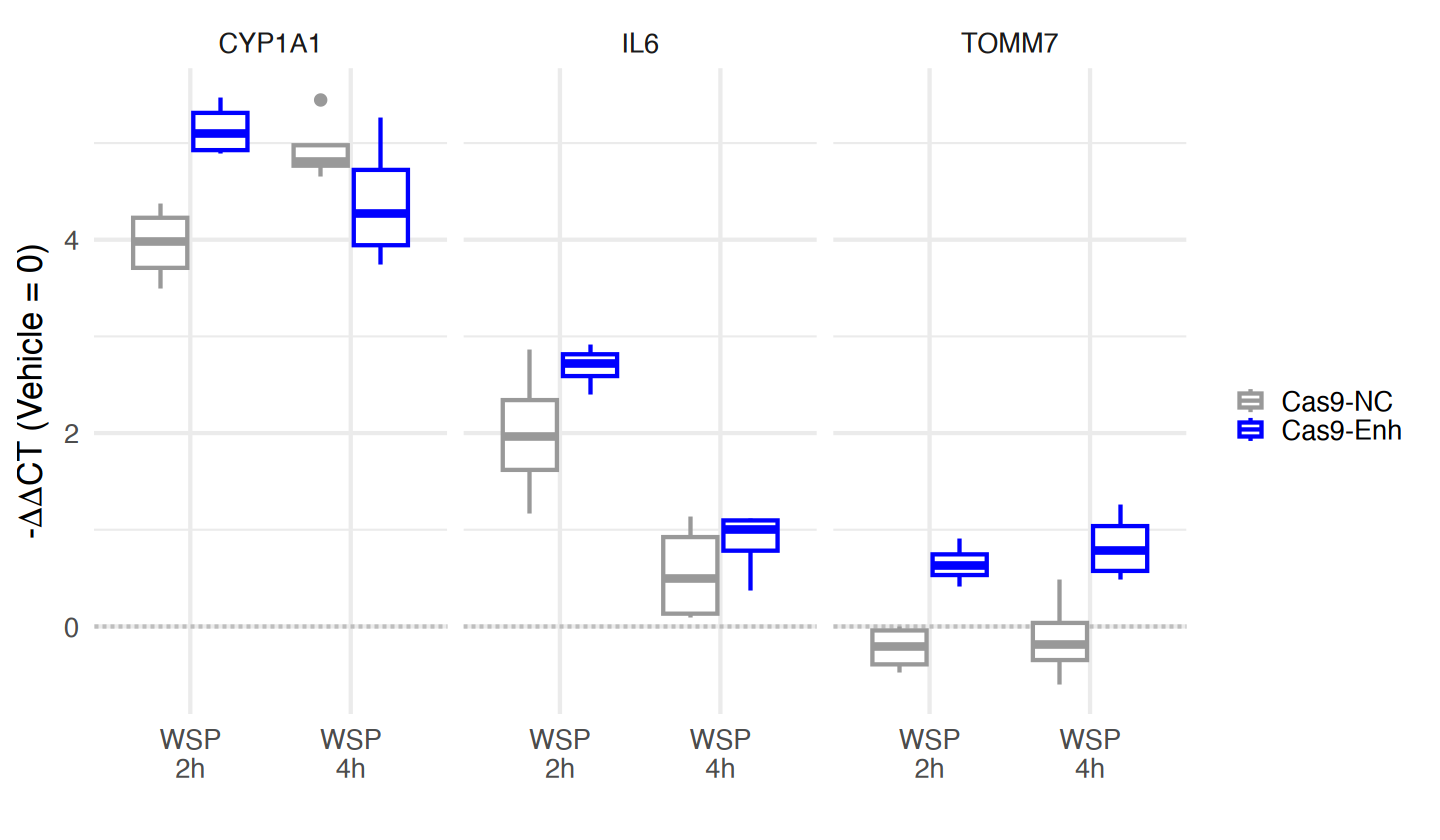

In [ ]:
options(repr.plot.width=12)
plot_function(qpcr_plot[qpcr_plot$X != "Veh" & qpcr_plot$Date == "2.27.26" & !is.na(qpcr_plot$value),], stat_2_df)

#ggsave("./plots/qPCR_ACTN1Enh.pdf", width=8, height=6)


ggplot(qpcr_plot[qpcr_plot$X != "Veh" & qpcr_plot$Date == "3.6.26" & !is.na(qpcr_plot$value),],
aes(x=X, y=-value, color=factor(Strain, levels=c("Cas9-NC", "Cas9-Enh")))) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  #geom_jitter(width=0.1, size=2) +
  facet_wrap(~gene, nrow=1) +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"), color="") 
#ggsave("./plots/qPCR_ACTN1Enh.pdf", width=8, height=6)

ggplot(qpcr_plot[qpcr_plot$X != "Veh" & qpcr_plot$Date == "3.18.26" & !is.na(qpcr_plot$value),],
aes(x=X, y=-value, color=factor(Strain, levels=c("Cas9-NC", "Cas9-Enh")))) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  #geom_jitter(width=0.1, size=2) +
  facet_wrap(~gene, nrow=1) +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"), color="") 
#ggsave("./plots/qPCR_ACTN1Enh.pdf", width=8, height=6)



In [38]:
unique(qpcr_plot[qpcr_plot$X != "Veh" & qpcr_plot$Date == "3.6.26" & !is.na(qpcr_plot$value),]$gene)

[1] "CYP1A1" "TOMM7"  "IL6"

X,gene,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif,xmin,xmax
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
WSP 4h,CYP1A1,value,Cas9-Enh,Cas9-NC,4,4,11,0.4860,0.4860,ns,CYP1A1,CYP1A1
WSP 4h,IL6,value,Cas9-Enh,Cas9-NC,4,4,16,0.0286,0.0429,*,IL6,IL6
WSP 4h,TOMM7,value,Cas9-Enh,Cas9-NC,4,4,16,0.0286,0.0429,*,TOMM7,TOMM7


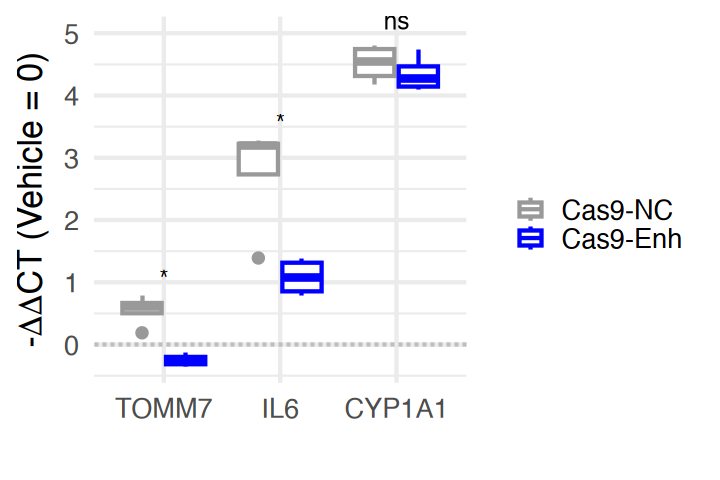

In [55]:
stat_df <- qpcr_plot[qpcr_plot$Date == "3.6.26" & !is.na(qpcr_plot$value),] %>%
  filter(X == "WSP\n4h") %>%
  group_by(gene, X) %>%                     # WITHIN each gene and condition
  wilcox_test(value ~ Strain) %>%           # non-parametric test
  adjust_pvalue(method = "BH") %>%          # optional, but recommended
  add_significance("p.adj", cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 0.1, 1),
       symbols = c("****", "***", "**", "*", ".", "ns")) %>%
  ungroup() %>%
  mutate(
    xmin = gene,
    xmax = gene
  )
stat_df
stat_df$y.position = c(5, 3.5, 1)

options(repr.plot.width=6, repr.plot.height=4)
ggplot(qpcr_plot[qpcr_plot$X == "WSP\n4h" & qpcr_plot$Date == "3.6.26" & !is.na(qpcr_plot$value),],
aes(x=factor(gene, levels=c("TOMM7", "IL6", "CYP1A1")), y=-value, color=factor(Strain, levels=c("Cas9-NC", "Cas9-Enh")))) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  #geom_jitter(width=0.1, size=2) +
  #facet_wrap(~gene, nrow=1) +
  stat_pvalue_manual(
    stat_df,
	xmin = "xmin", xmax="xmax",
    label = "p.adj.signif",  size=5,  # or "p" if you want exact values
    tip.length = 0.01,
    hide.ns = FALSE
  ) +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"), color="") 
ggsave("plots/qRTPCR_TOMM7IL6.pdf", width=6, height=4)


In [63]:
unique(qpcr_plot$Date)

[1] "2.27.26" "3.6.26"  "3.18.26"

X,gene,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif,xmin,xmax
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
WSP 4h,CYP1A1,value,Cas9-Enh,Cas9-NC,4,4,13,0.2000,0.3000,ns,CYP1A1,CYP1A1
WSP 4h,IL6,value,Cas9-Enh,Cas9-NC,4,4,5,0.4860,0.4860,ns,IL6,IL6
WSP 4h,TOMM7,value,Cas9-Enh,Cas9-NC,4,4,1,0.0571,0.1713,ns,TOMM7,TOMM7


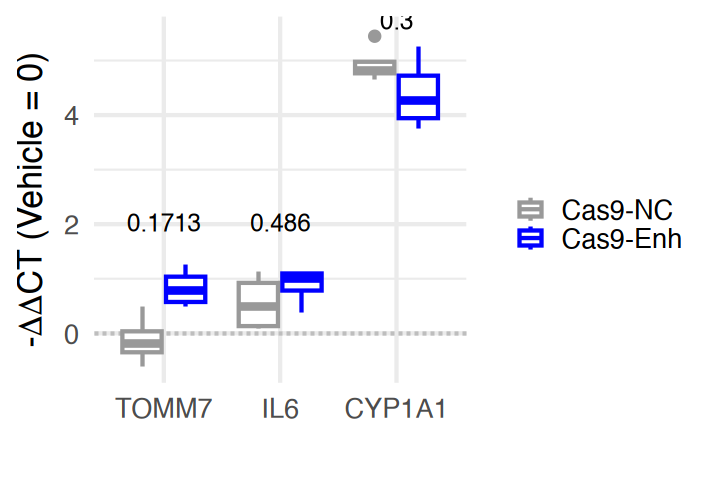

In [61]:
stat_df <- qpcr_plot[qpcr_plot$Date == "3.18.26" & !is.na(qpcr_plot$value),] %>%
  filter(X == "WSP\n4h") %>%
  group_by(gene, X) %>%                     # WITHIN each gene and condition
  wilcox_test(value ~ Strain) %>%           # non-parametric test
  adjust_pvalue(method = "BH") %>%          # optional, but recommended
  add_significance("p.adj", cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 0.1, 1),
       symbols = c("****", "***", "**", "*", ".", "ns")) %>%
  ungroup() %>%
  mutate(
    xmin = gene,
    xmax = gene
  )
stat_df
stat_df$y.position = c(5.5, 1.8, 1.8)

options(repr.plot.width=6, repr.plot.height=4)
ggplot(qpcr_plot[qpcr_plot$X == "WSP\n4h" & qpcr_plot$Date == "3.18.26" & !is.na(qpcr_plot$value),],
aes(x=factor(gene, levels=c("TOMM7", "IL6", "CYP1A1")), y=-value, color=factor(Strain, levels=c("Cas9-NC", "Cas9-Enh")))) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  #geom_jitter(width=0.1, size=2) +
  #facet_wrap(~gene, nrow=1) +
  stat_pvalue_manual(
    stat_df,
	xmin = "xmin", xmax="xmax",
    label = "p.adj",  size=5,  # or "p" if you want exact values
    tip.length = 0.01,
    hide.ns = FALSE
  ) +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"), color="") 
#ggsave("plots/qRTPCR_TOMM7IL6.pdf", width=6, height=4)


X,gene,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif,xmin,xmax
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
WSP 2h,CYP1A1,value,Cas9-Enh,Cas9-NC,4,4,0,0.0286,0.0429,*,CYP1A1,CYP1A1
WSP 2h,IL6,value,Cas9-Enh,Cas9-NC,4,4,3,0.2000,0.2000,ns,IL6,IL6
WSP 2h,TOMM7,value,Cas9-Enh,Cas9-NC,4,4,0,0.0286,0.0429,*,TOMM7,TOMM7


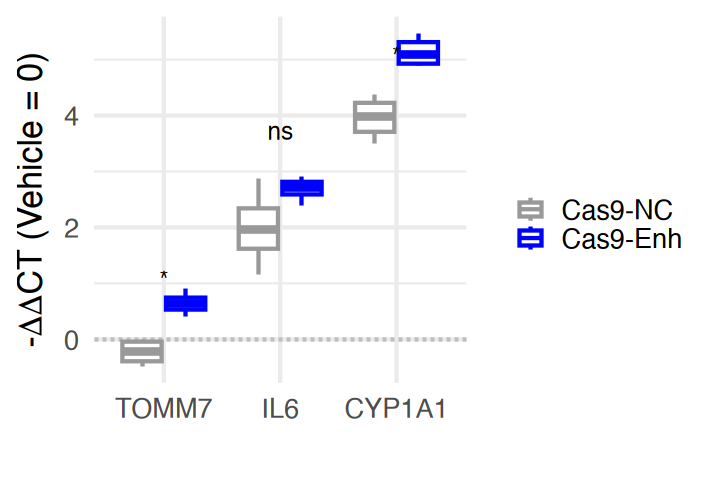

In [58]:
stat_df <- qpcr_plot[qpcr_plot$Date == "3.18.26" & !is.na(qpcr_plot$value),] %>%
  filter(X == "WSP\n2h") %>%
  group_by(gene, X) %>%                     # WITHIN each gene and condition
  wilcox_test(value ~ Strain) %>%           # non-parametric test
  adjust_pvalue(method = "BH") %>%          # optional, but recommended
  add_significance("p.adj", cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 0.1, 1),
       symbols = c("****", "***", "**", "*", ".", "ns")) %>%
  ungroup() %>%
  mutate(
    xmin = gene,
    xmax = gene
  )
stat_df
stat_df$y.position = c(5, 3.5, 1)

options(repr.plot.width=6, repr.plot.height=4)
ggplot(qpcr_plot[qpcr_plot$X == "WSP\n2h" & qpcr_plot$Date == "3.18.26" & !is.na(qpcr_plot$value),],
aes(x=factor(gene, levels=c("TOMM7", "IL6", "CYP1A1")), y=-value, color=factor(Strain, levels=c("Cas9-NC", "Cas9-Enh")))) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  #geom_jitter(width=0.1, size=2) +
  #facet_wrap(~gene, nrow=1) +
  stat_pvalue_manual(
    stat_df,
	xmin = "xmin", xmax="xmax",
    label = "p.adj.signif",  size=5,  # or "p" if you want exact values
    tip.length = 0.01,
    hide.ns = FALSE
  ) +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"), color="") 
ggsave("plots/qRTPCR_TOMM7IL6.pdf", width=6, height=4)


## HYA Analysis

In [105]:
qpcr <- read_excel("../results/From_Arnav/qPCR_Summary.xlsx")
qpcr[1:2,]

qpcr$X <- paste0(qpcr$Perturbation, "\n", qpcr$Time)
qpcr[qpcr$Perturbation == "Veh",]$X <- "Veh"
table(qpcr$Date)

Sample Name,Perturbation,Time,Date,sm,RPL19,CEMIPa,HAS1,HAS2,HAS3,HYAL1,HYAL2,HYAL3,CEMIPa_norm,HAS1_norm,HAS2_norm,HAS3_norm,HYAL1_norm,HYAL2_norm,HYAL3_norm
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
v1,Veh,NA,10.06.25,sm36,21.04680,25.71086,34.60431,30.65951,25.31298,29.16894,24.82260,26.88924,4.664061,13.55752,9.612711,4.26618,8.122143,3.775805,5.842447
v2,Veh,NA,10.06.25,sm36,20.98769,25.89435,37.28129,31.08987,25.52812,29.12843,24.77774,26.57572,4.906656,16.29360,10.102180,4.54043,8.140739,3.790054,5.588034



 1.16.26 10.06.25 11.25.25 
      38       20       20 

In [106]:
library(dplyr)
library(stringr)
library(tidyr)
get_veh_subtracted_df <- function(df) {
	# Identify normalized gene columns
gene_cols <- grep("_norm$", names(df), value = TRUE)
df <- df %>% select(-c("Date")) # remove HAS1 because way too low
#print(df[1:2,])
df2 <- df %>%
  # Compute average Vehicle value per sm
  left_join(
    df %>% 
      filter(Perturbation == "Veh") %>%
      group_by(sm) %>%
      summarise(
        across(
          all_of(gene_cols),
          ~ median(.x, na.rm = TRUE),
          .names = "{.col}_veh_mean"
        ),
        .groups = "drop"
      ),
    by = "sm"
  ) %>%
  
  # Subtract mean Veh value per sm
  mutate(
    across(
      all_of(gene_cols),
      ~ .x - get(paste0(cur_column(), "_veh_mean")),
      .names = "{.col}_adj"
    )
  ) %>%
  
  # Optional cleanup of the temporary mean columns
  select(`Sample Name`, X, sm, ends_with("_norm_adj")) 
  # Get the long version for plotting
  # Identify adjusted gene columns
adj_cols <- grep("_norm_adj$", names(df2), value = TRUE)

df_long <- df2 %>%
  pivot_longer(
    cols = all_of(adj_cols),
    names_to = "gene",
    values_to = "value"
  ) %>%
  mutate(
    gene = sub("_norm_adj$", "", gene)  # clean gene names for plotting
  )
}
qpcr_plot= get_veh_subtracted_df(qpcr[qpcr$Date == "1.16.26",])
qpcr_plot$Date <- "1.16.26"

qpcr_plot2= get_veh_subtracted_df(qpcr[qpcr$Date == "10.06.25",])
qpcr_plot2$Date <- "10.06.25"
qpcr_plot <- rbind(qpcr_plot2, qpcr_plot)

qpcr_plot2= get_veh_subtracted_df(qpcr[qpcr$Date == "11.25.25",])
qpcr_plot2$Date <- "11.25.25"
qpcr_plot <- rbind(qpcr_plot, qpcr_plot2)
dim(qpcr)
dim(qpcr_plot)
qpcr_plot[1:2,]

[1] 78 21

[1] 546   6

Sample Name,X,sm,gene,value,Date
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
v1,Veh,sm36,CEMIPa,0.1154585,10.06.25
v1,Veh,sm36,HAS1,-1.3680410,10.06.25


In [107]:
# calcualte fold change with 2^-value
qpcr_plot$FC <- 2^(-qpcr_plot$value)
qpcr_plot[1:2,]

Sample Name,X,sm,gene,value,Date,FC
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
v1,Veh,sm36,CEMIPa,0.1154585,10.06.25,0.9230889
v1,Veh,sm36,HAS1,-1.3680410,10.06.25,2.5811984


In [108]:
color_spec_dict = c("WSP\n3h" = "coral", "WSP\n6h" = "#f3602b",
 "UPM\n3h" = "grey30", "UPM\n6h" = "black")

Warning message:
"Removed 40 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 29 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


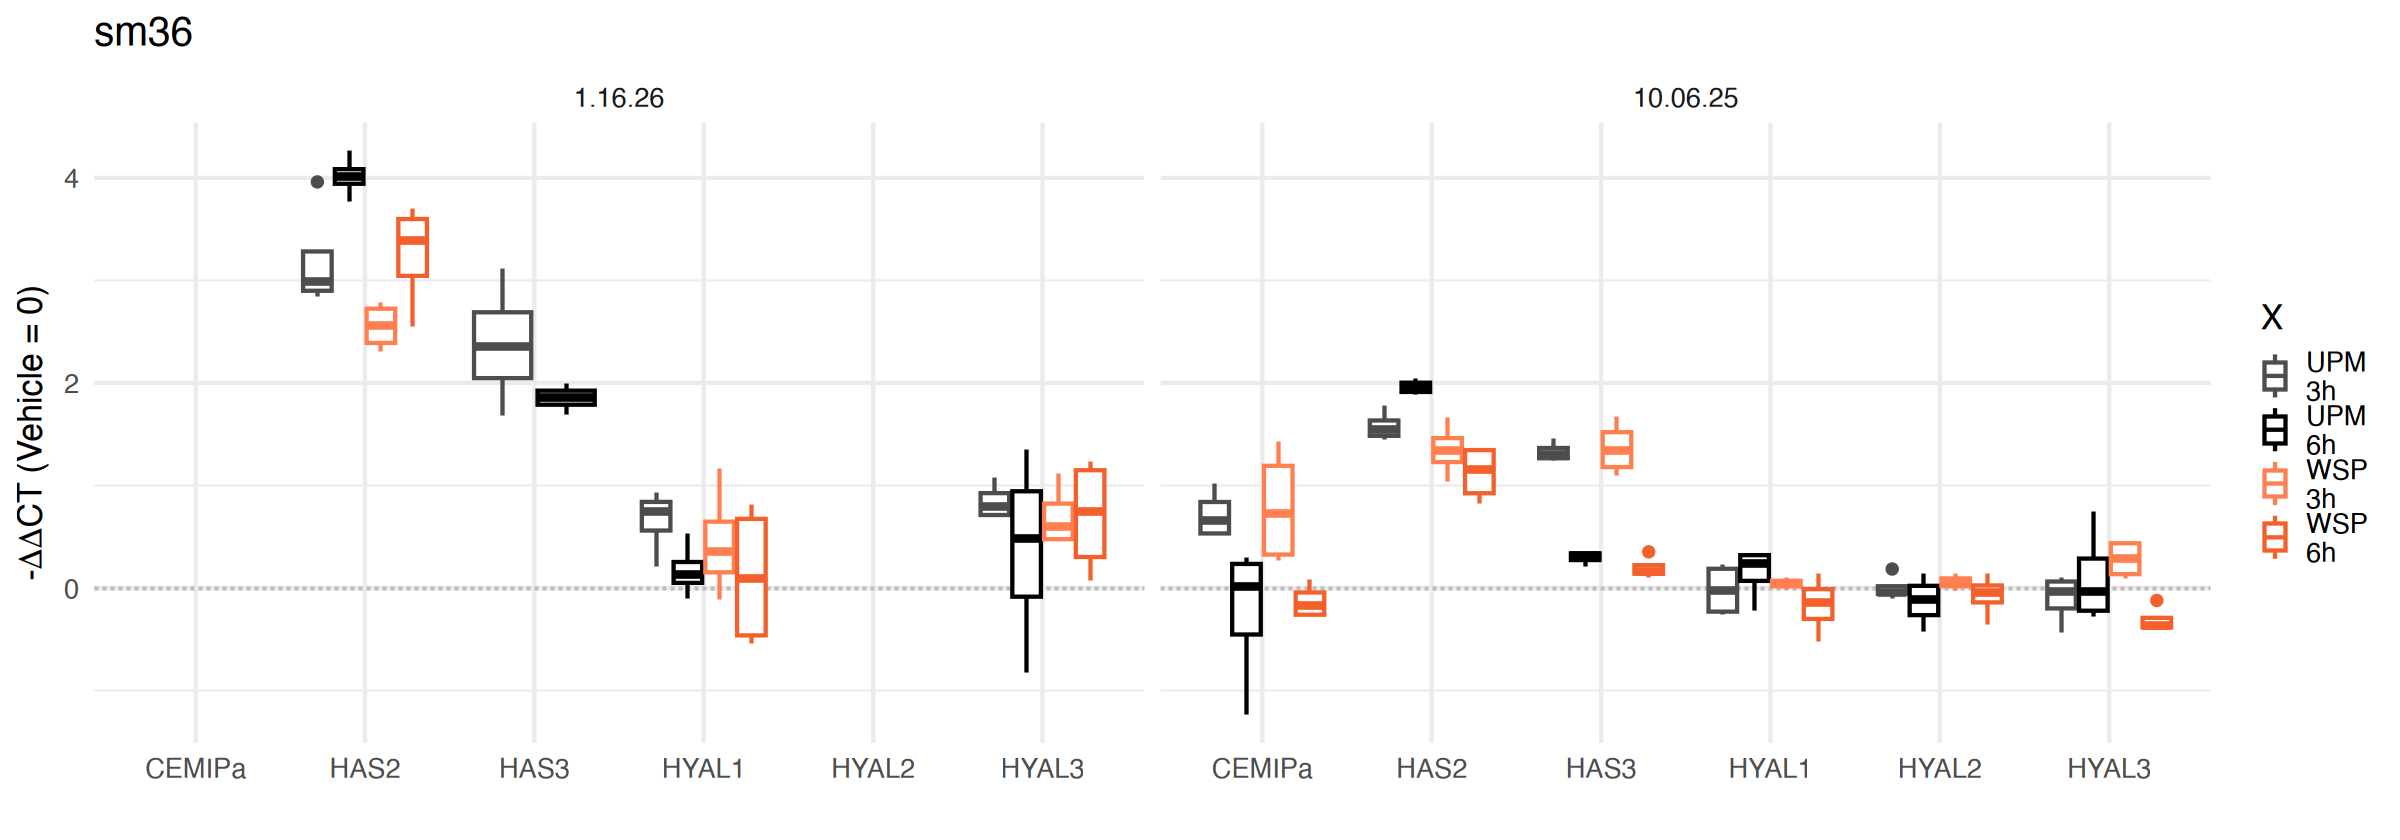

Warning message:
"Removed 40 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


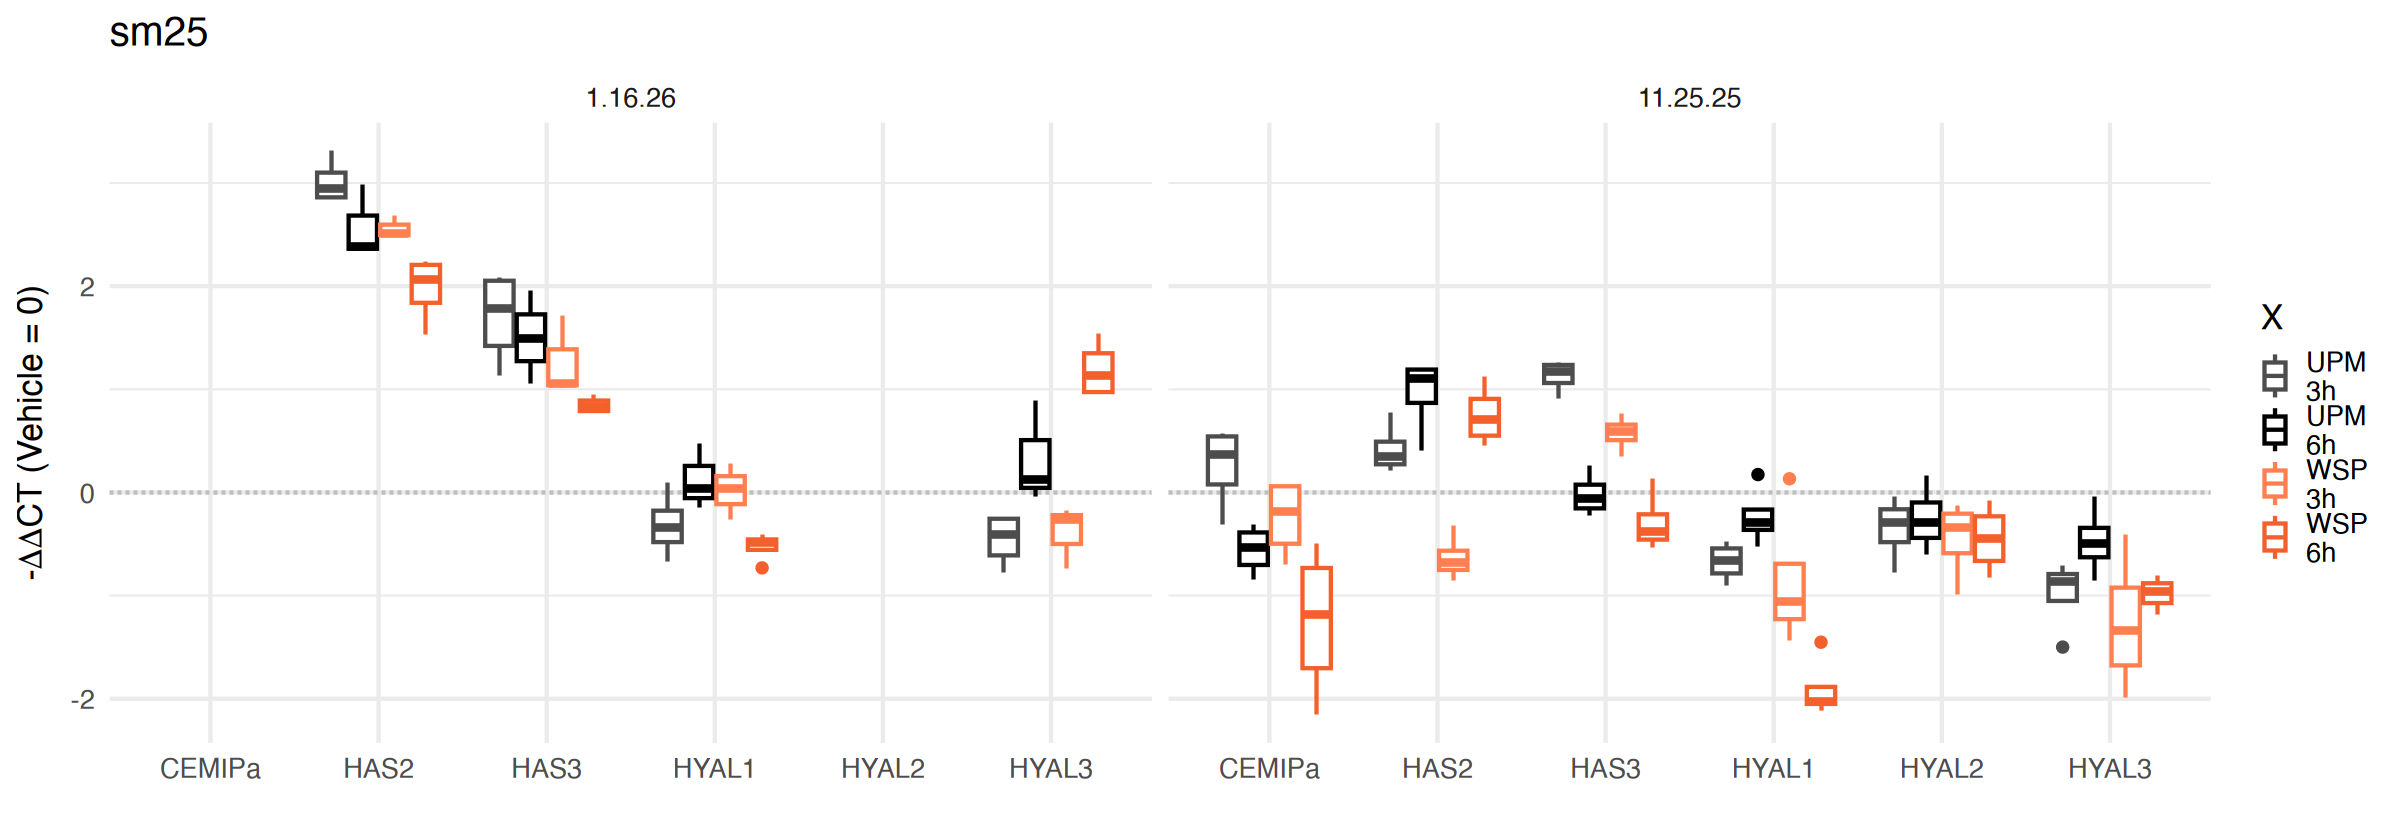

Warning message:
"Removed 29 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


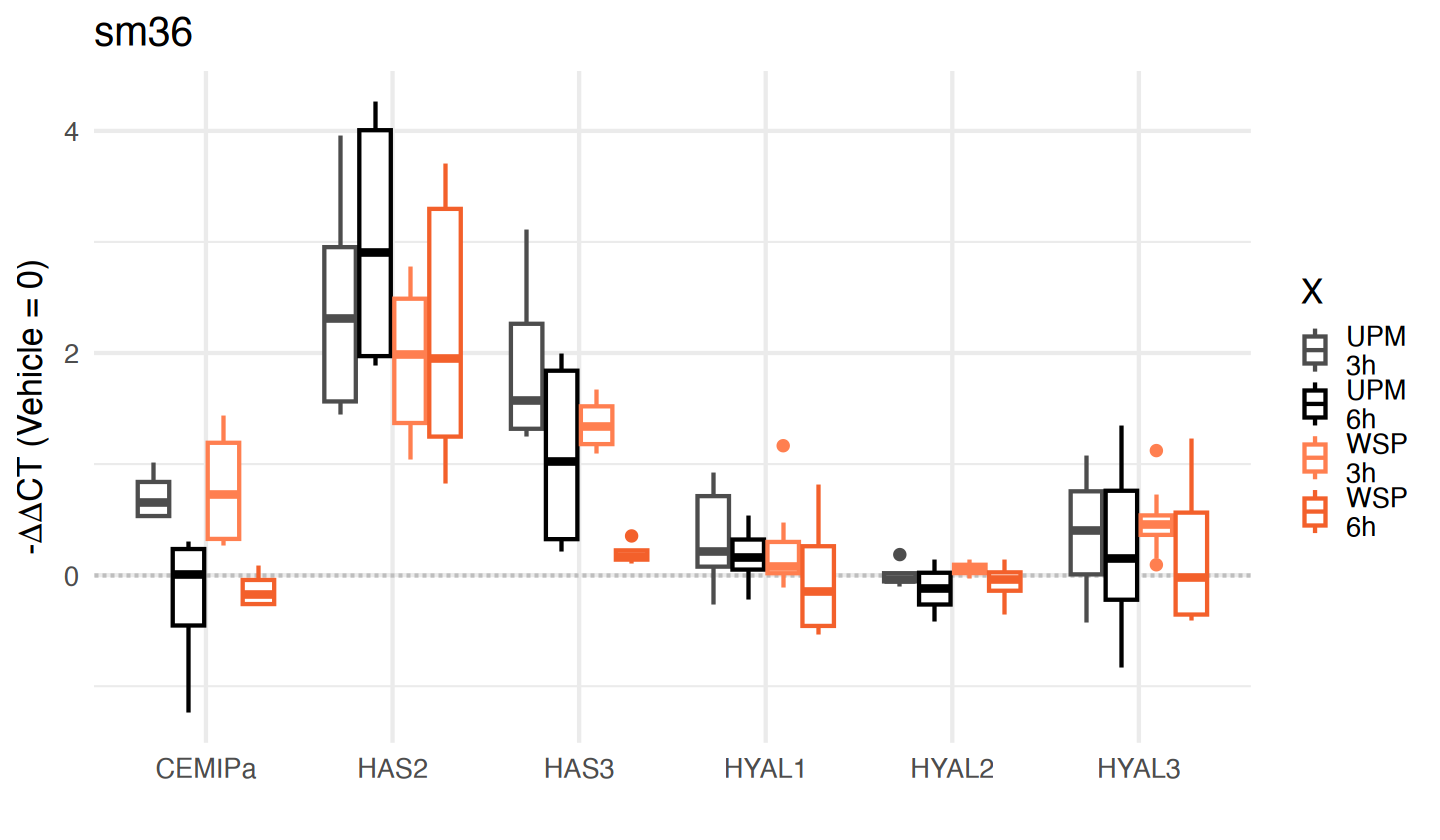

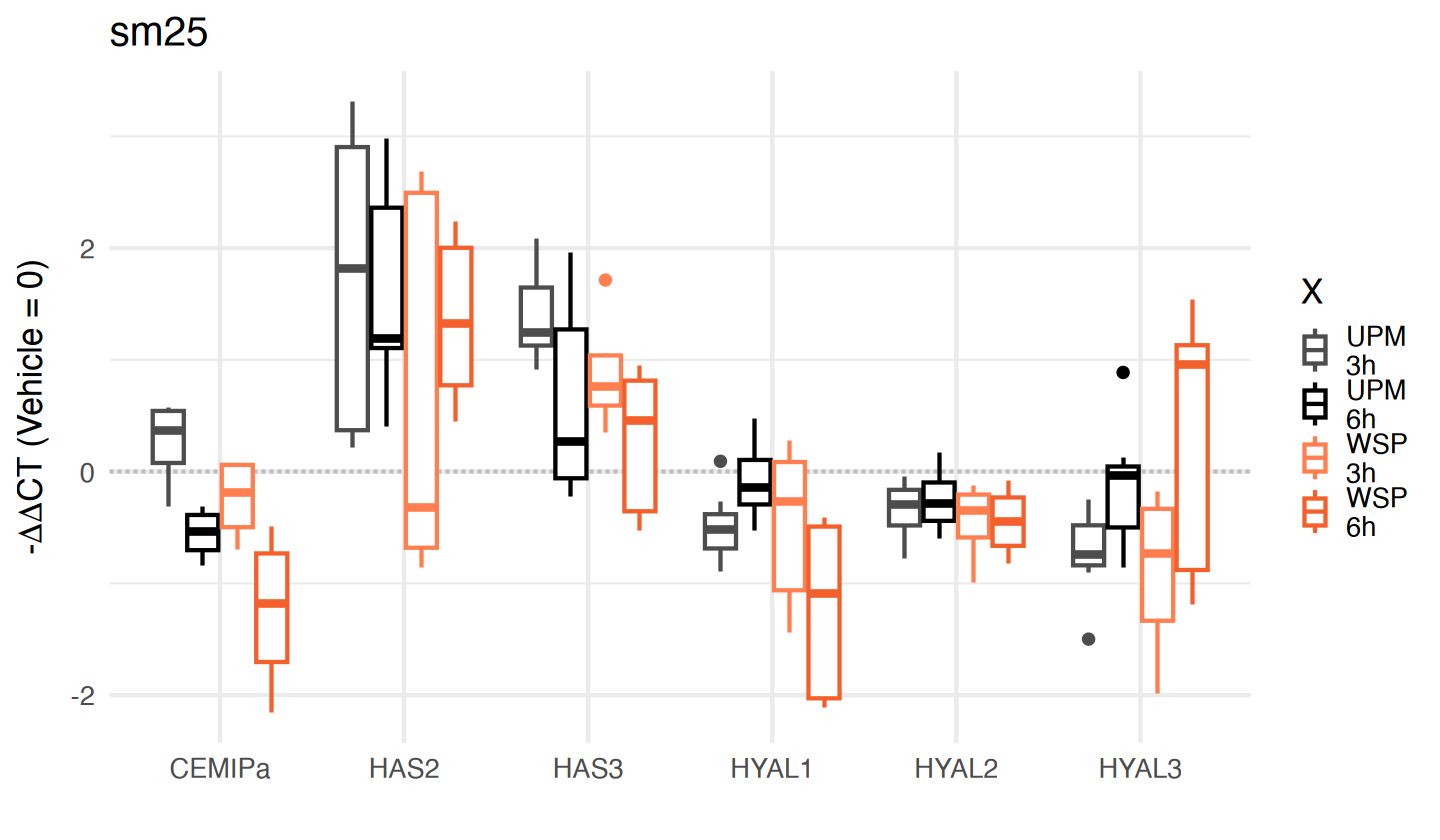

In [97]:
options(repr.plot.width=20)
genes_consider = c("CEMIPa", "HAS2", "HAS3", "HYAL1", "HYAL2", "HYAL3")
ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_consider,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_consider,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

options(repr.plot.width=12)
ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_consider,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + 
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_consider,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + 
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))
  

Genes that were consistent:
* HAS2 and HAS3 were continuously upregulated (although the timing varied where sometimes early rise but not 1.16.26 for either)
* HYAL1 * 3 seemed to be up or close to no change in sm36 and down for sm25. HYAL2 was down or no change.
* CEMIP1 was weird

Warning message:
"Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 15 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


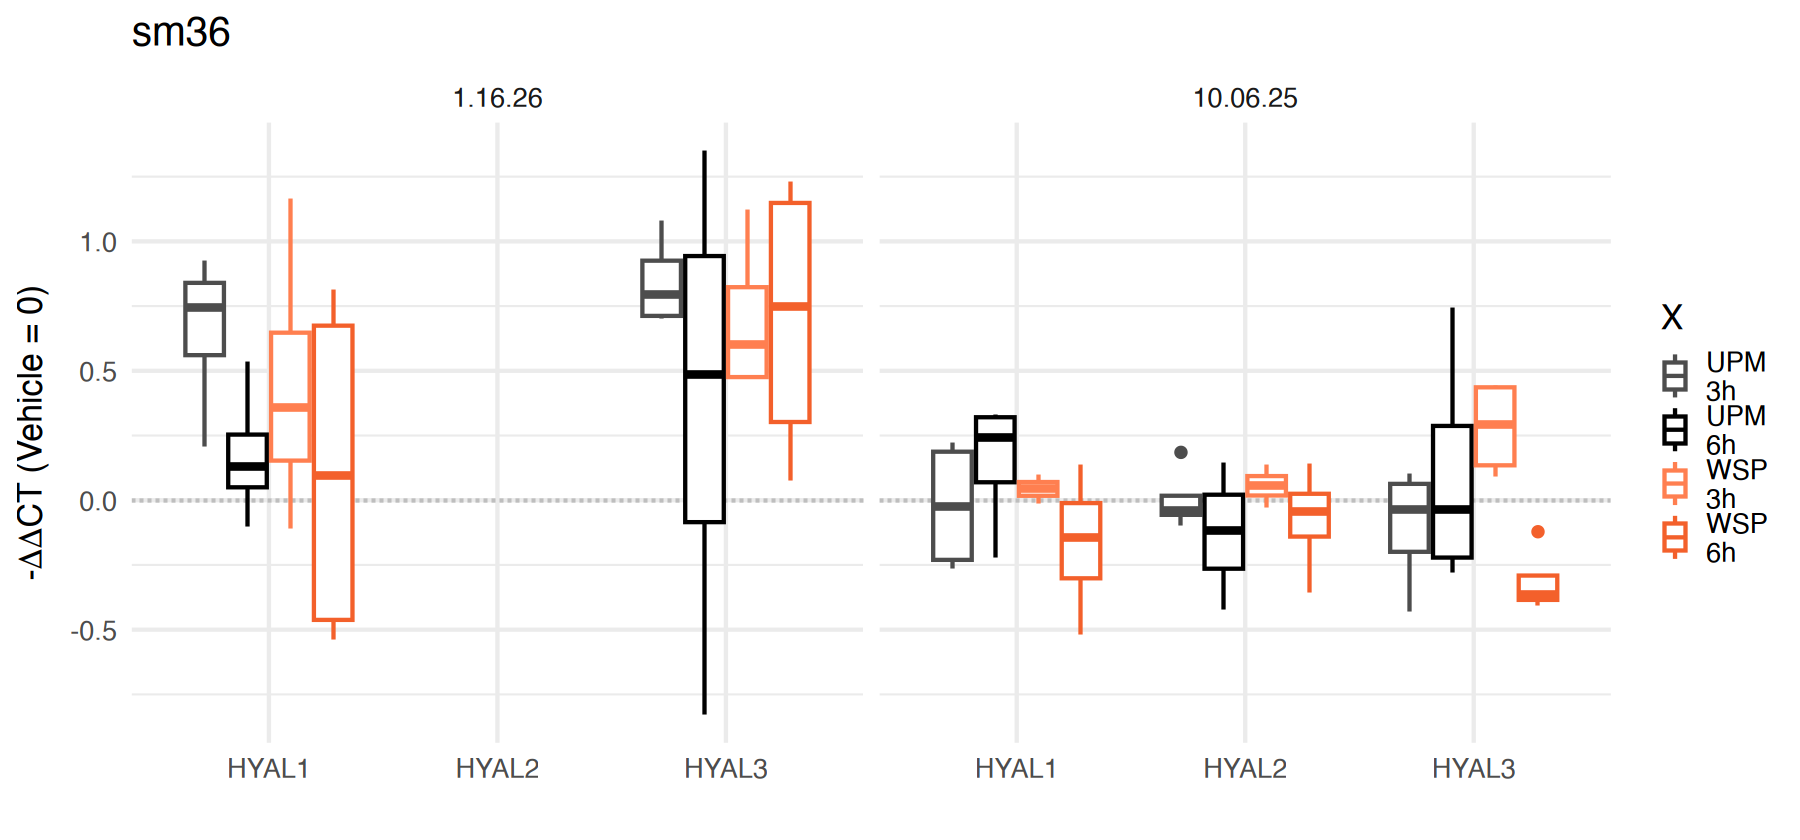

Warning message:
"Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


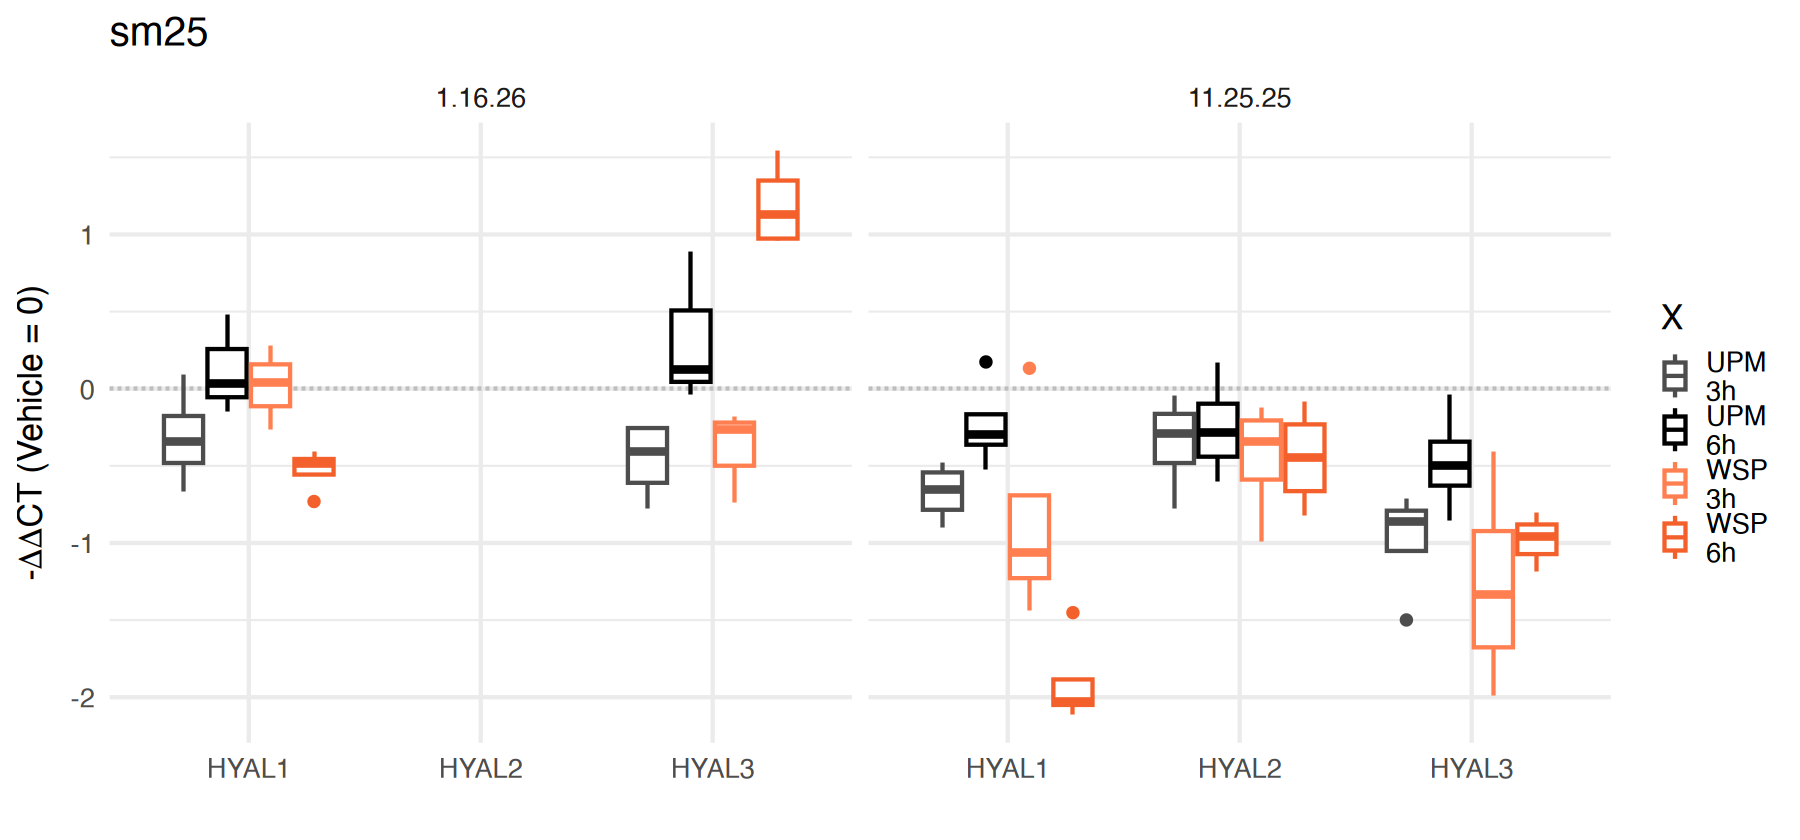

Warning message:
"Removed 15 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


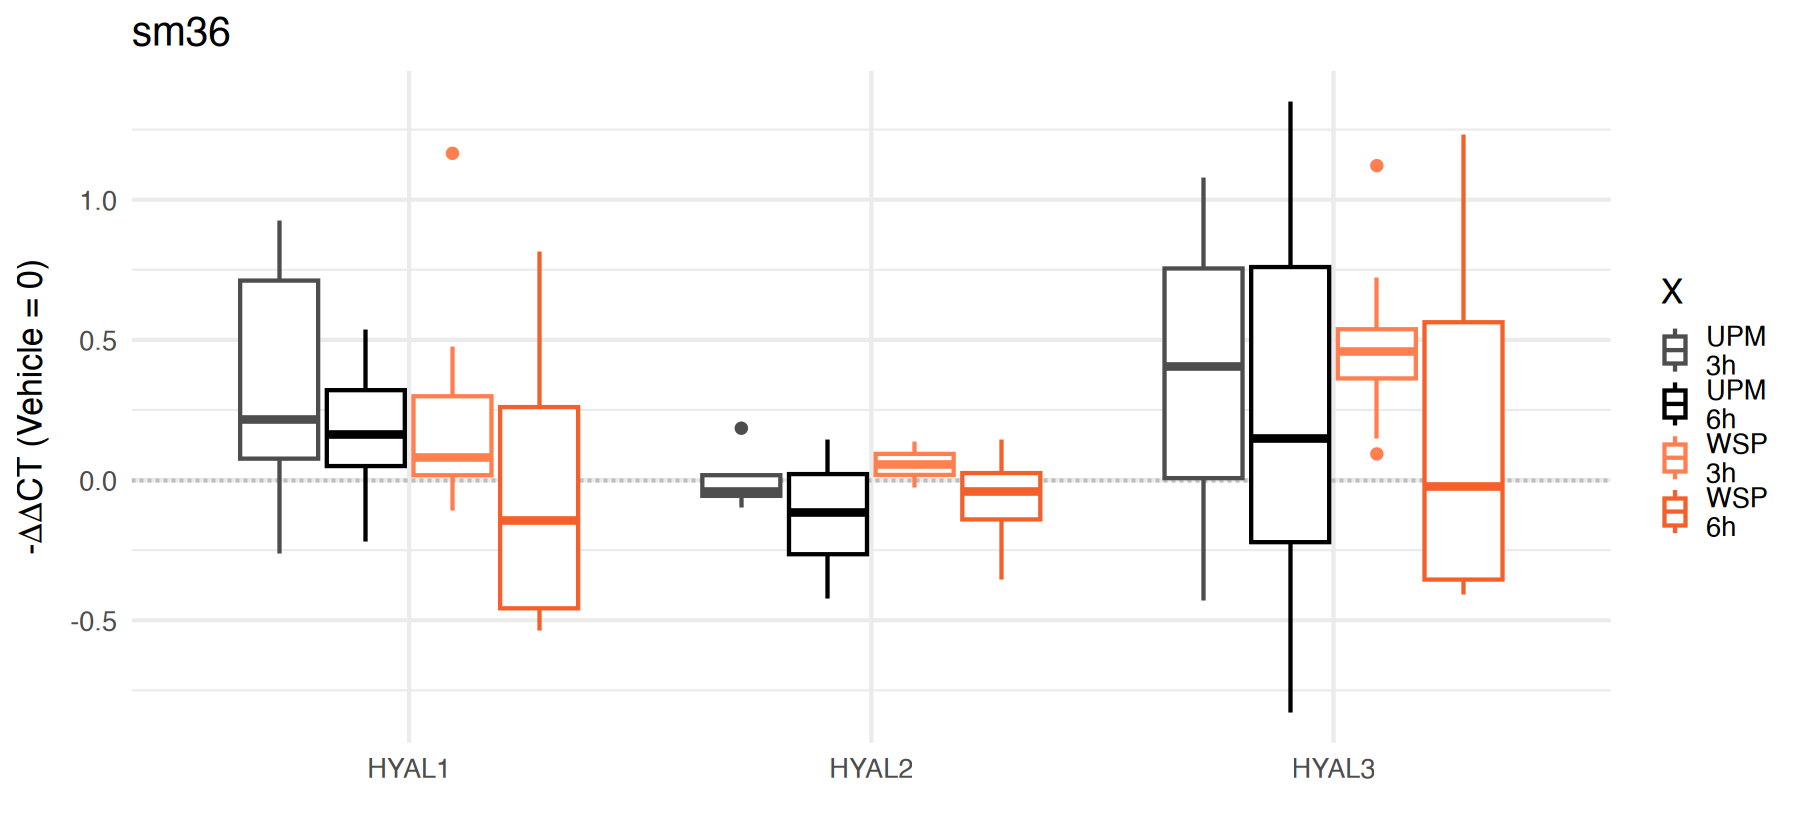

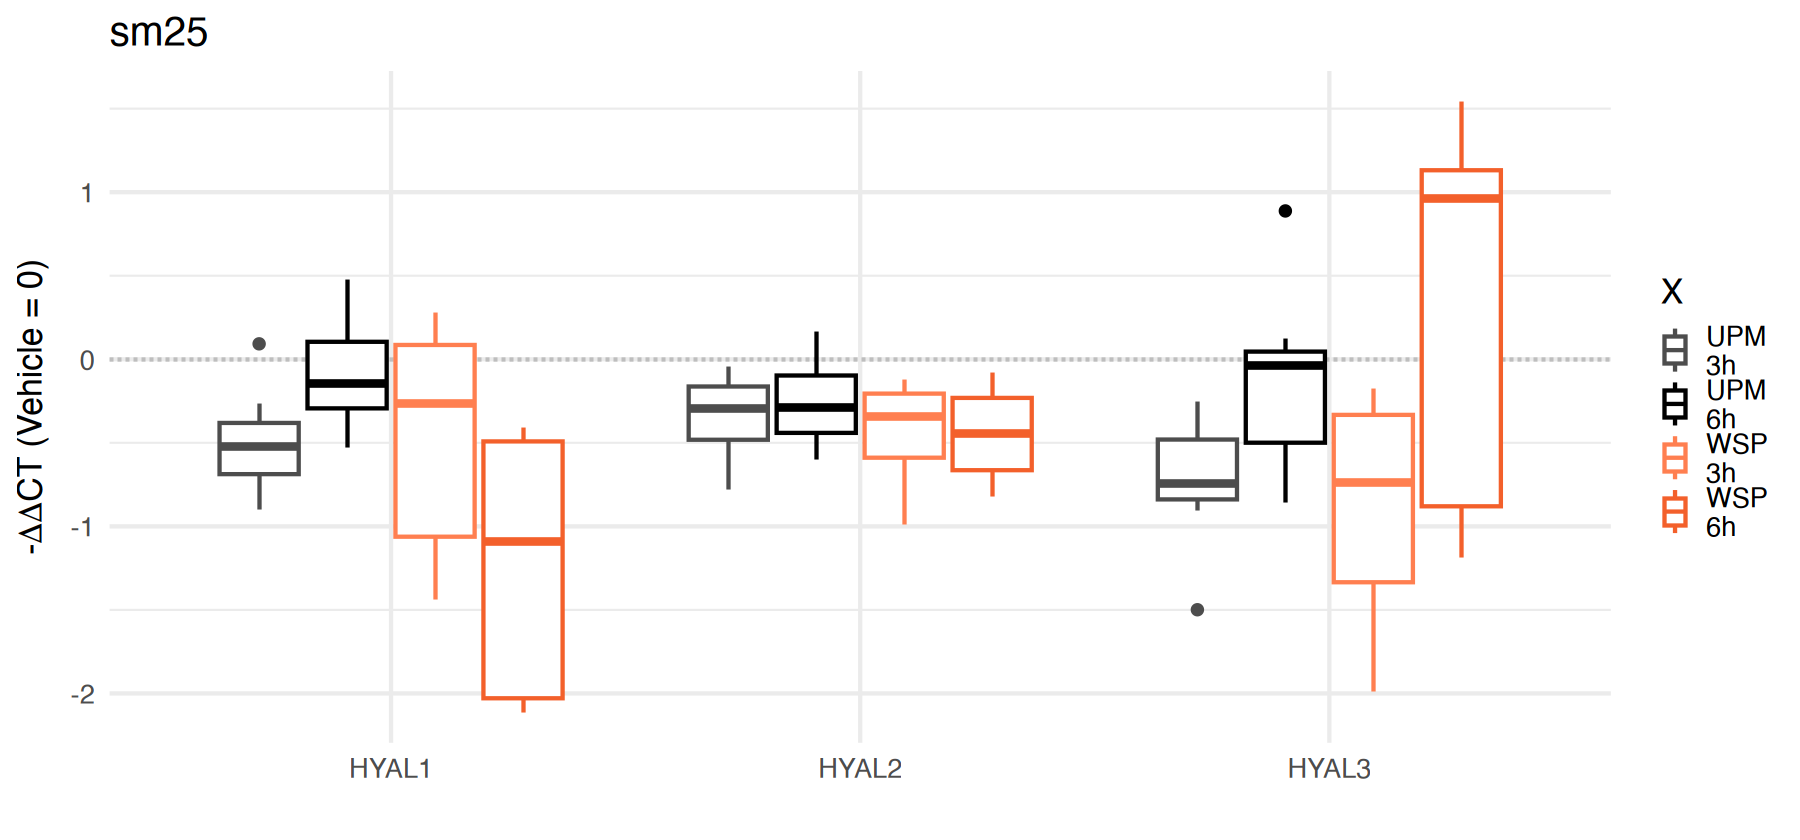

In [90]:
options(repr.plot.width=15)
genes_look = c("HYAL1", "HYAL2", "HYAL3")
ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

  ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + 
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + 
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

Warning message:
"Removed 8 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


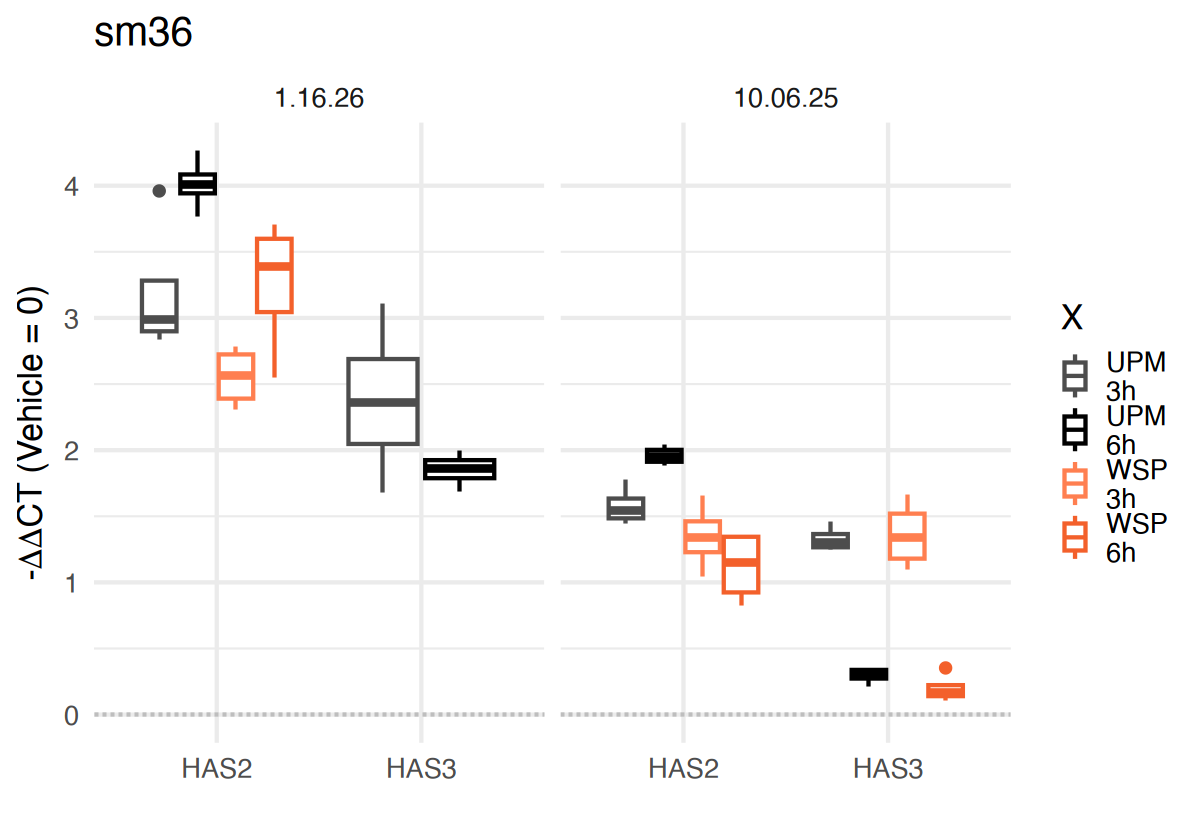

Warning message:
"Removed 8 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


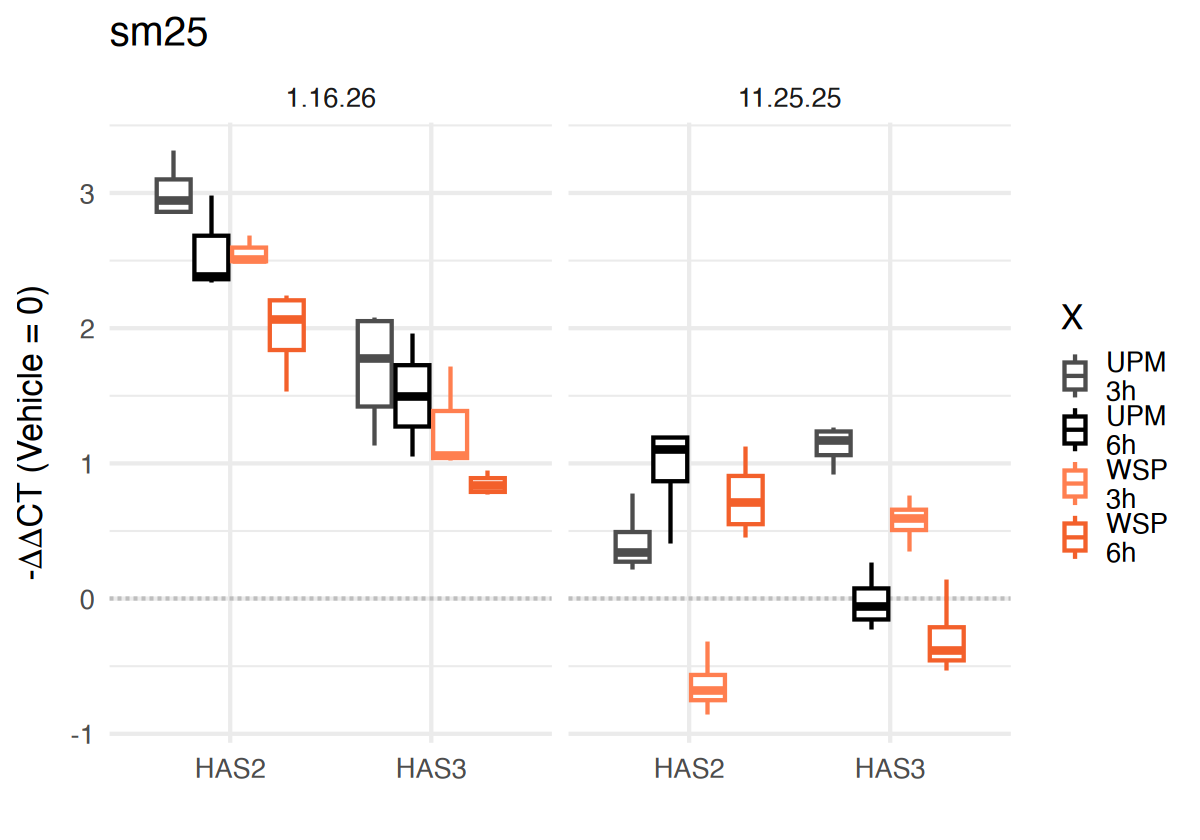

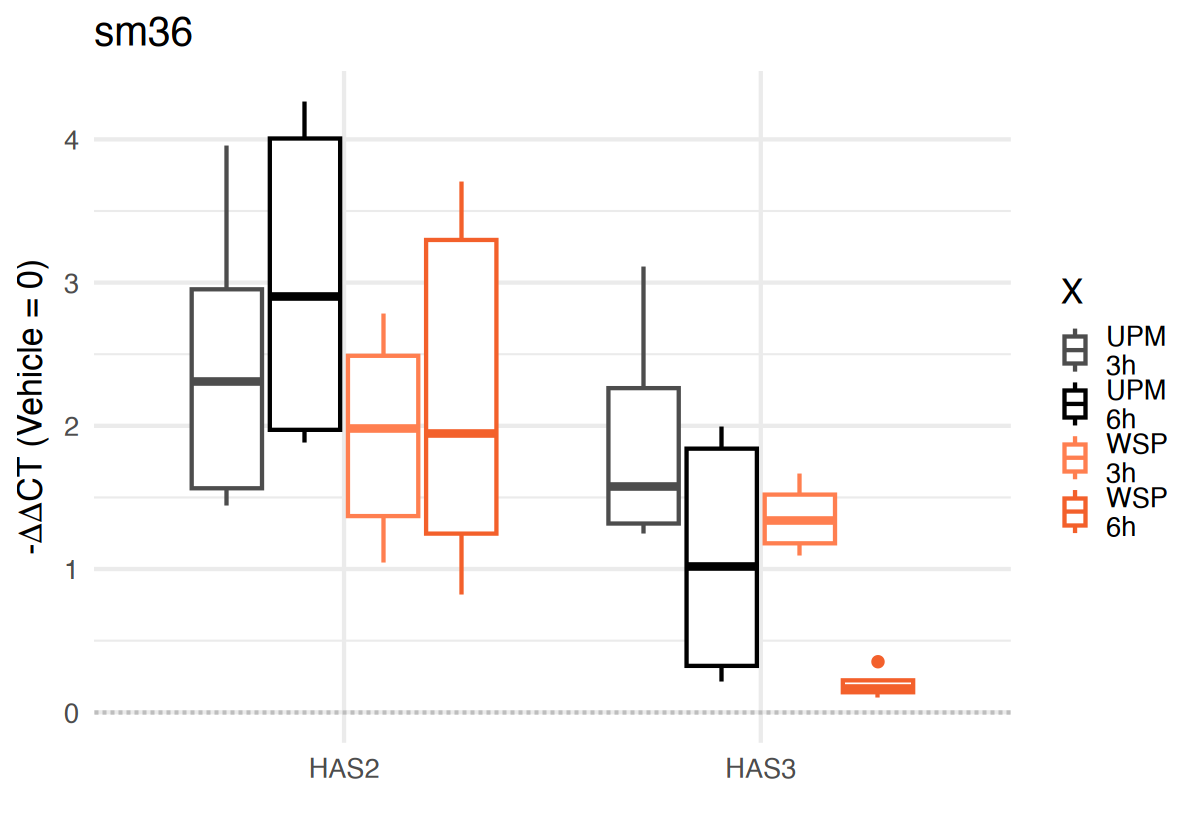

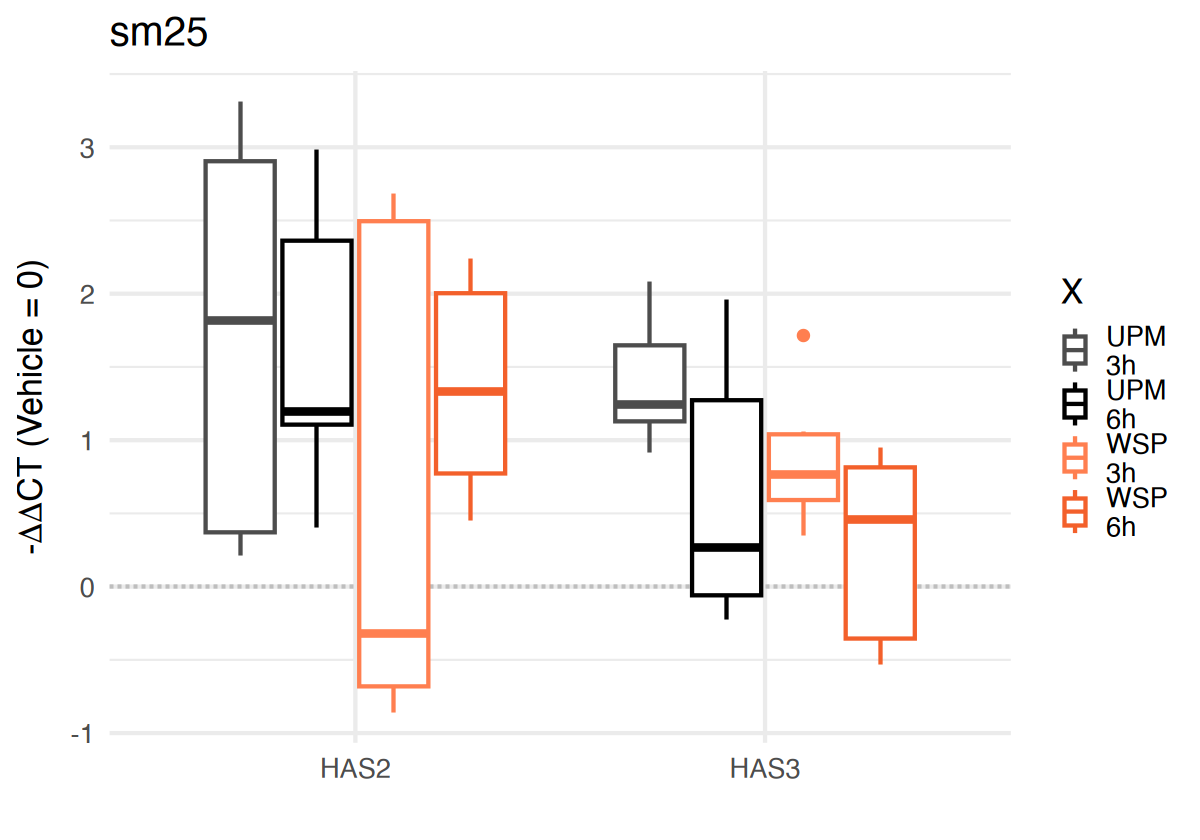

In [89]:
options(repr.plot.width=10)
genes_look = c("HAS2", "HAS3")
ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))


ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))


Warning message:
"Removed 24 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


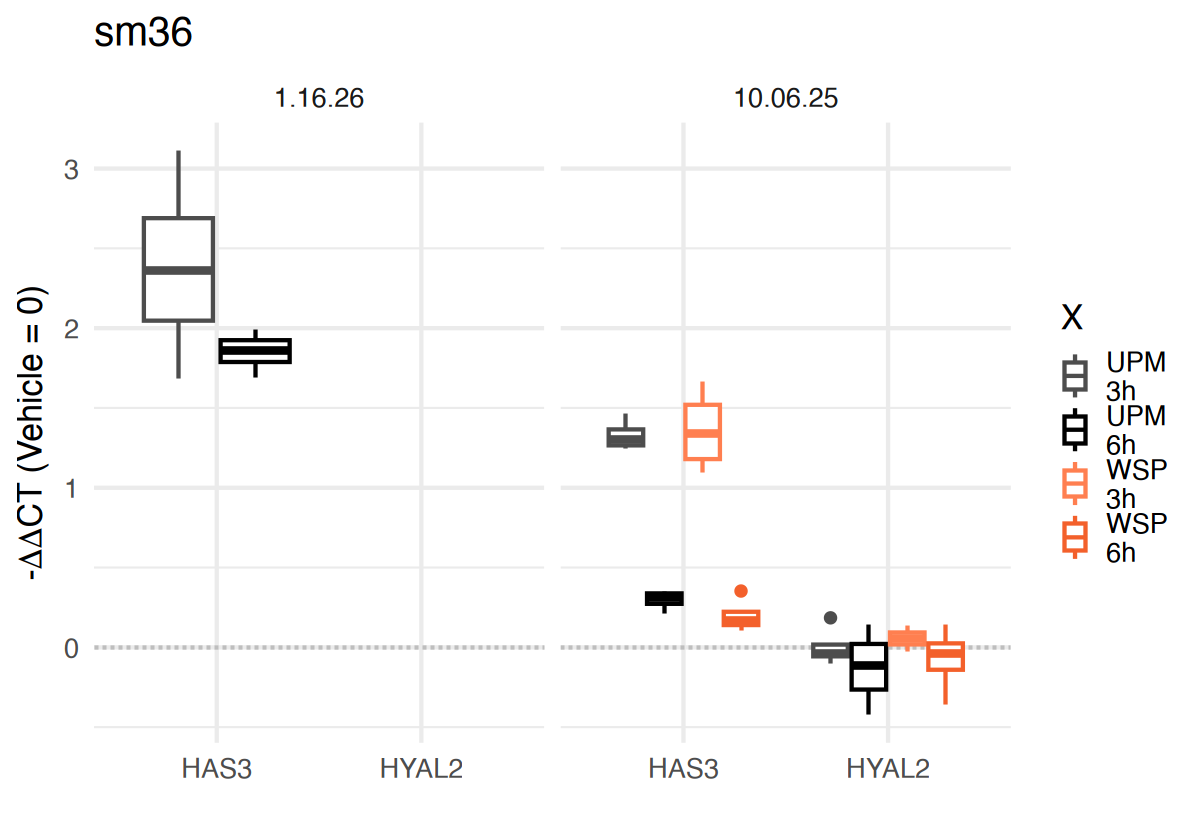

Warning message:
"Removed 24 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


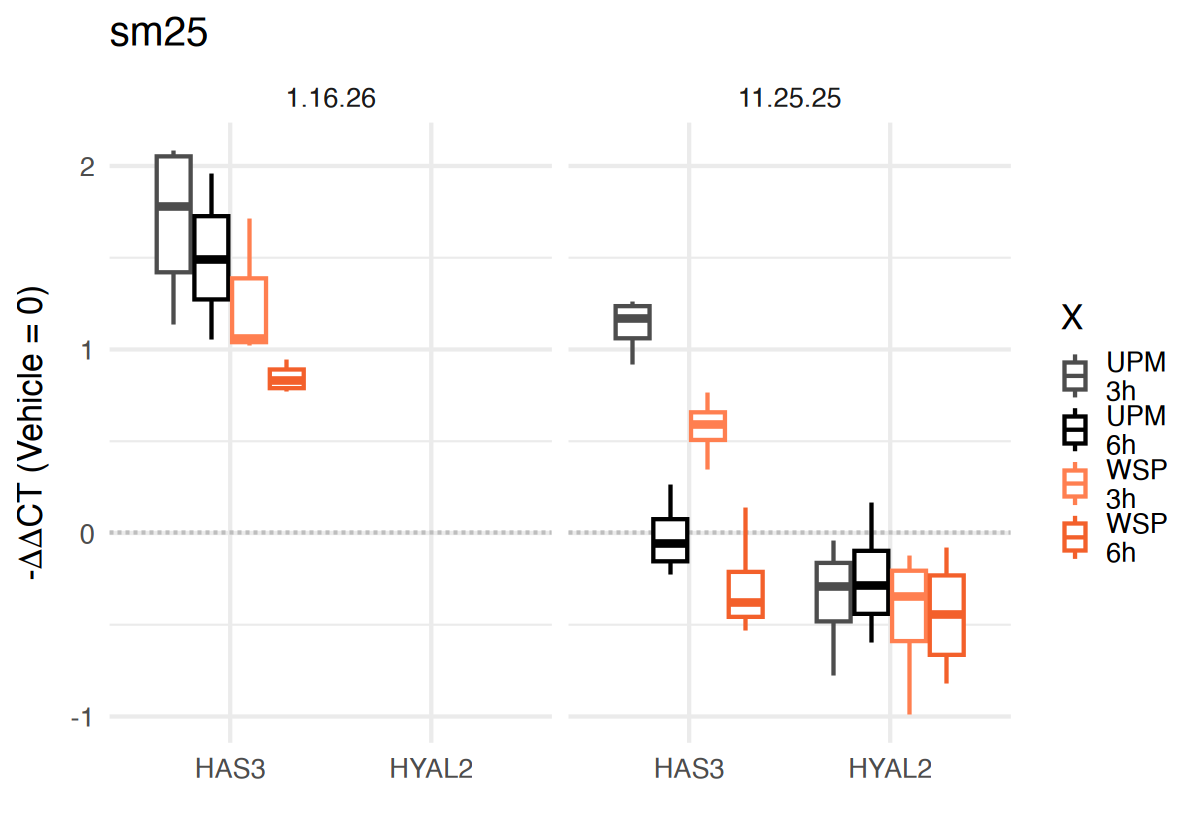

Warning message:
"Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


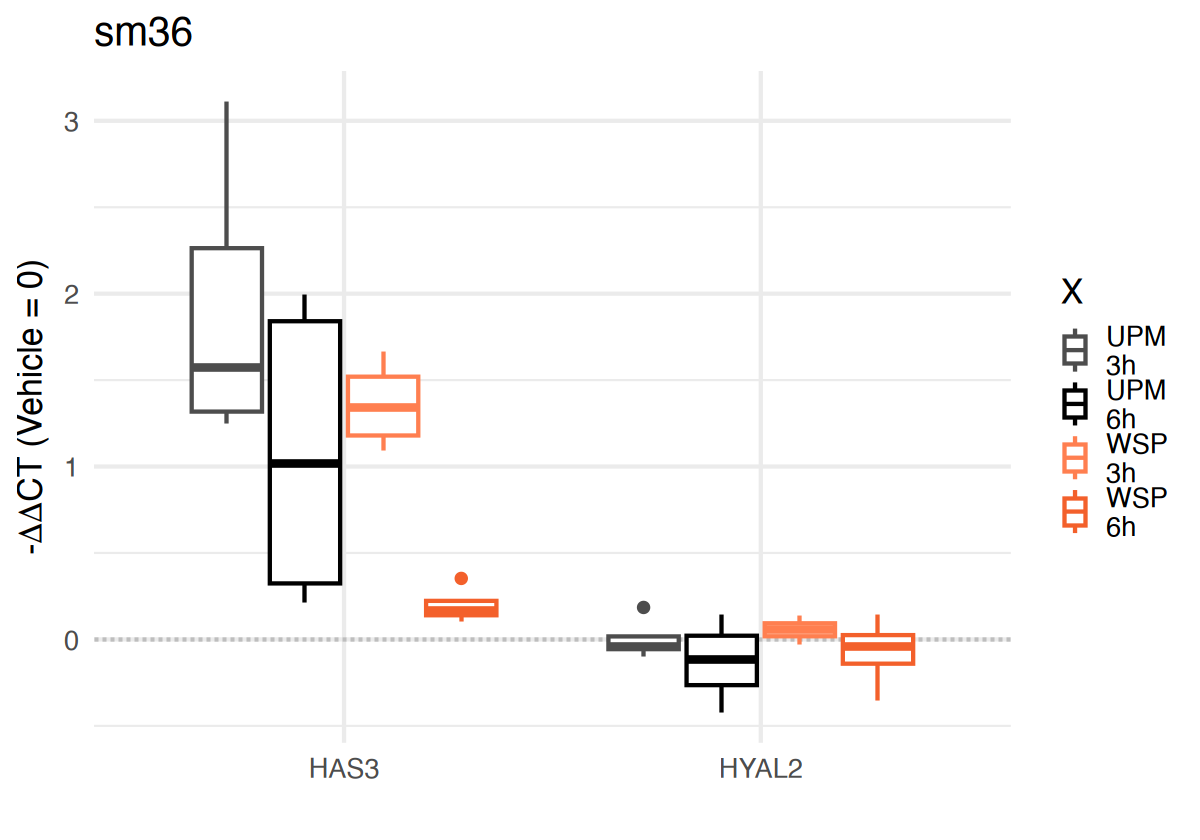

pdf 
  2

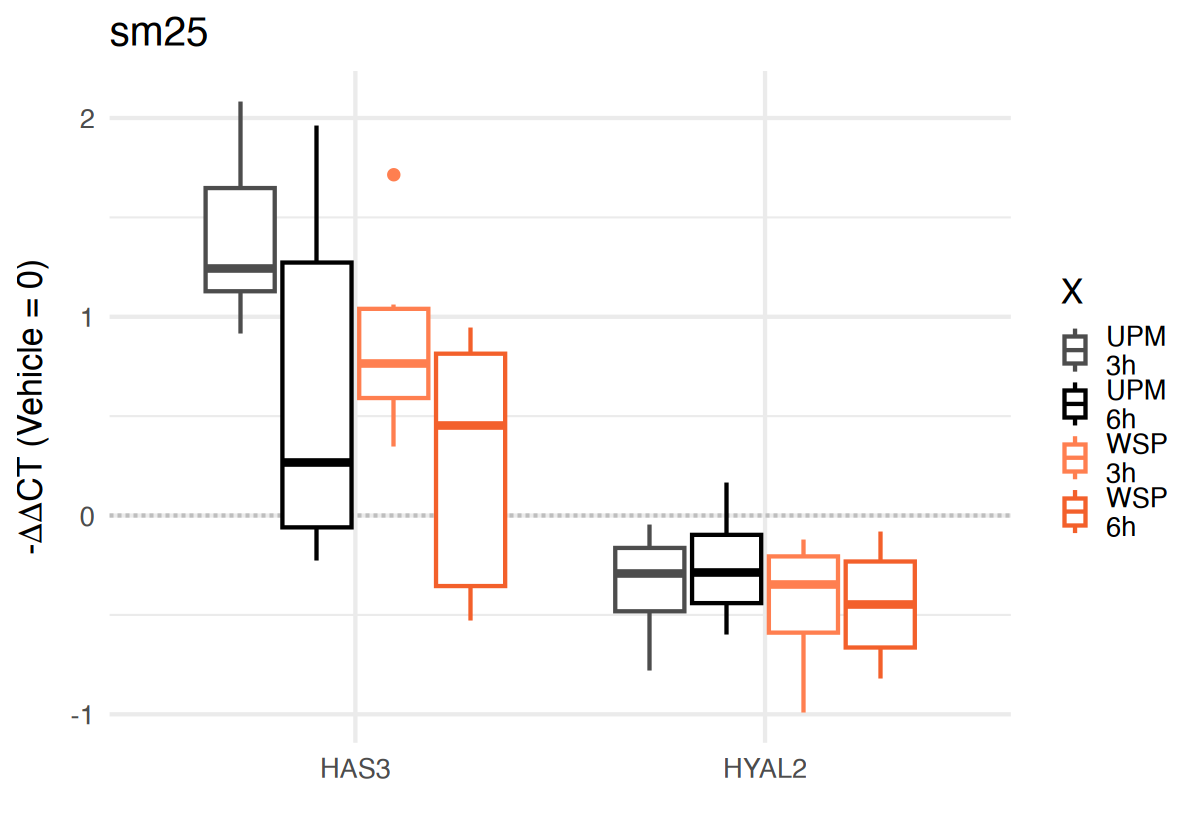

In [94]:
options(repr.plot.width=10)
genes_look = c("HYAL2", "HAS3")
ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))


ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))




pdf("./sm25_sm26_HASHYAL_2.23.26.pdf", width=8)
options(repr.plot.width=8)
  ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look & qpcr_plot$Date != "1.16.26",],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look & qpcr_plot$Date != "1.16.26",],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

dev.off()


Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."


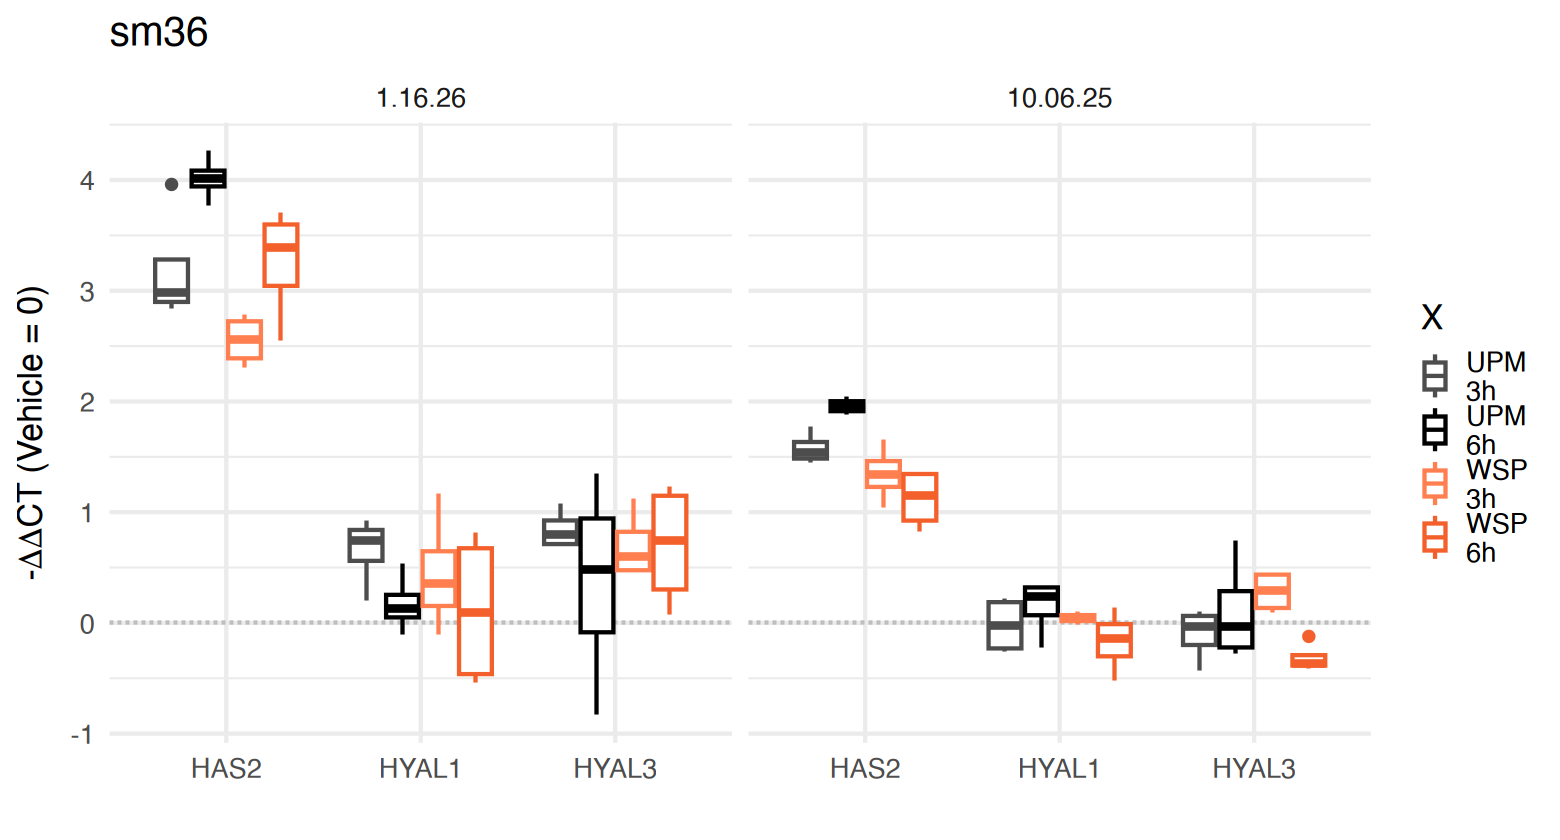

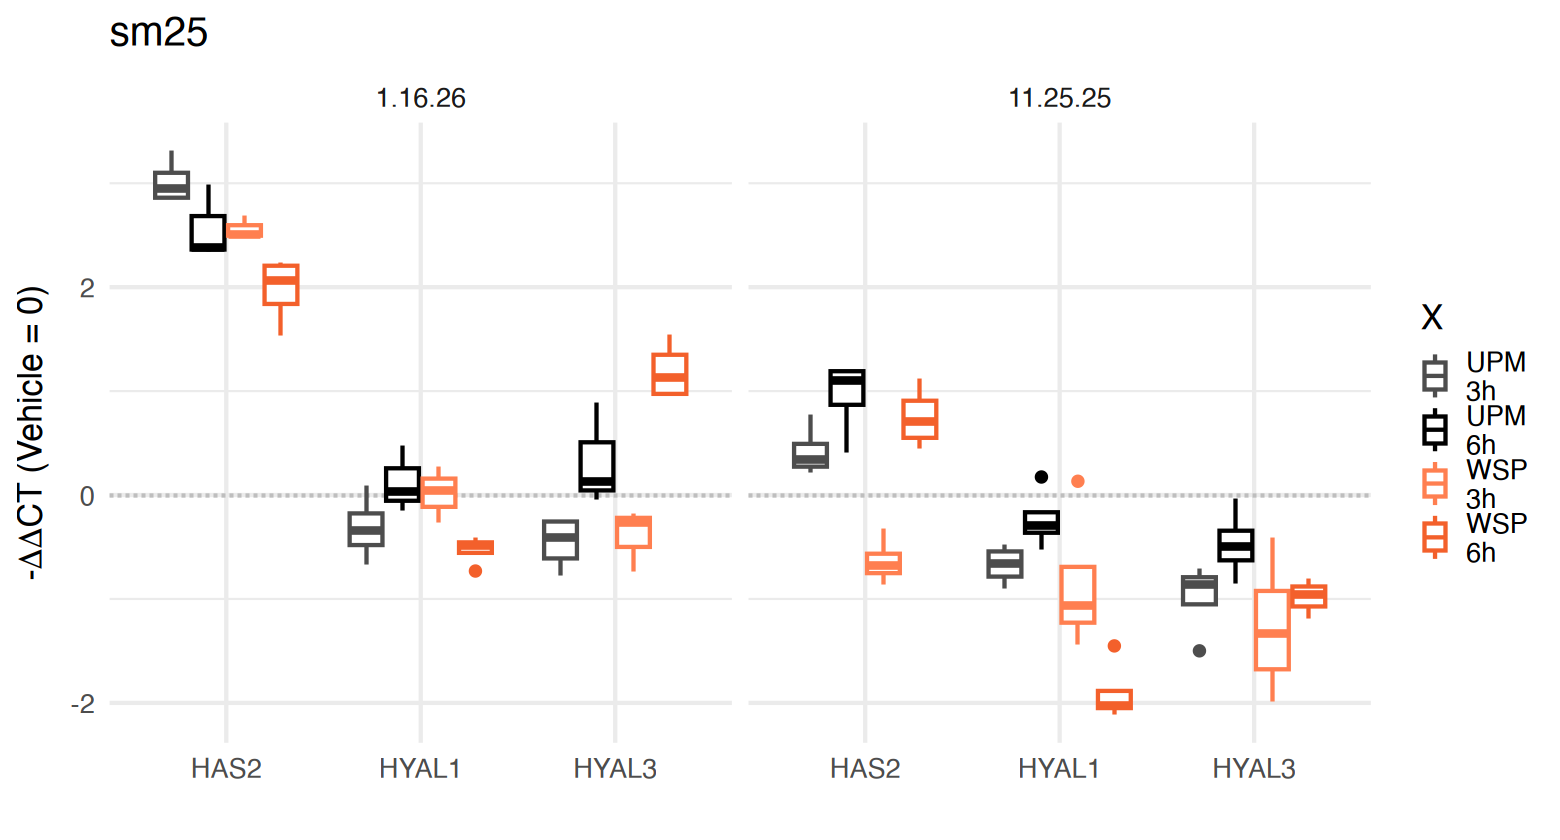

Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."


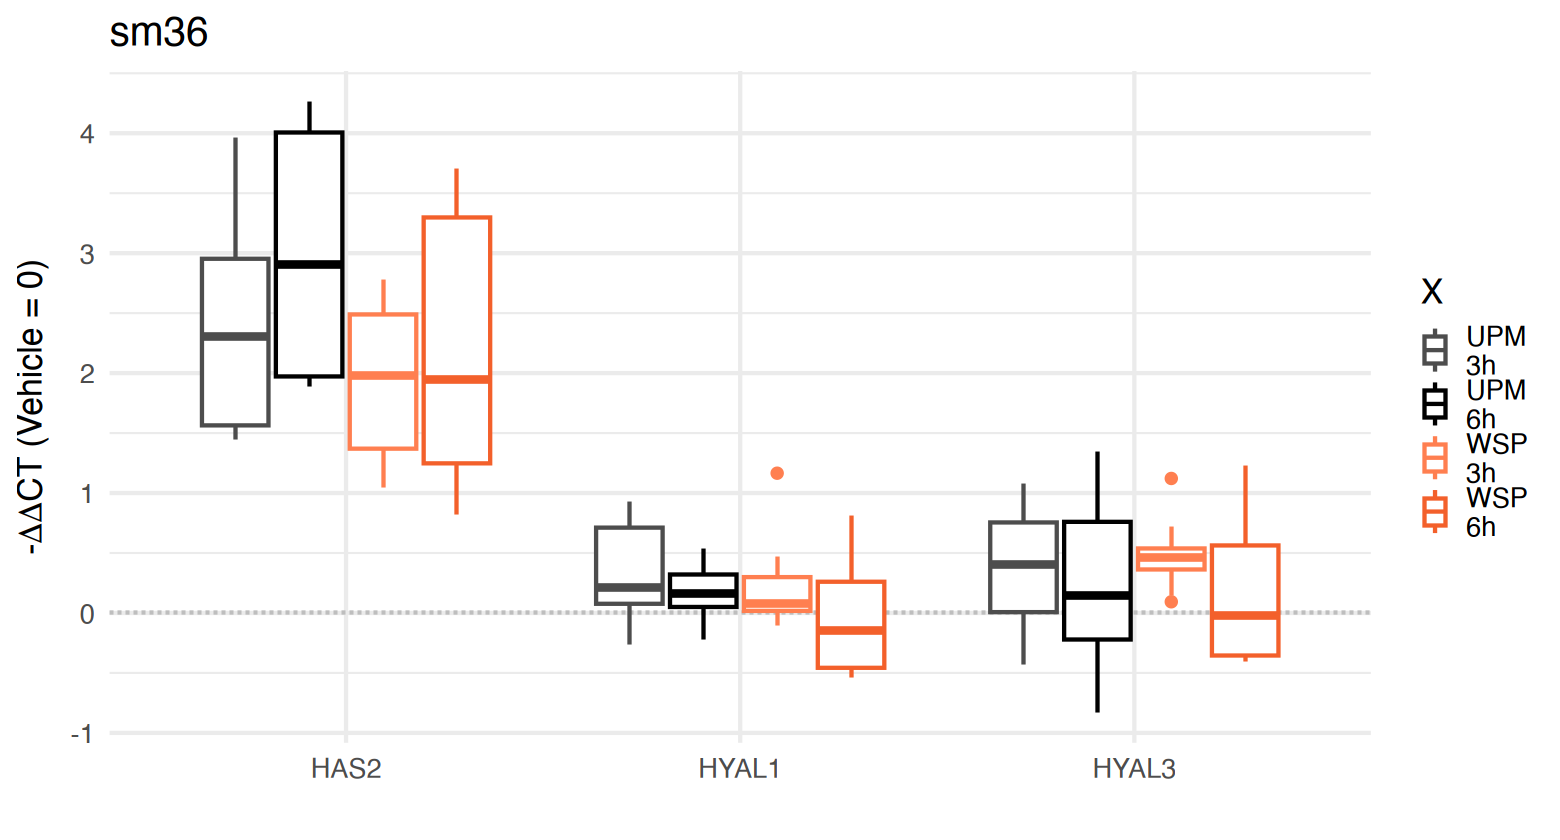

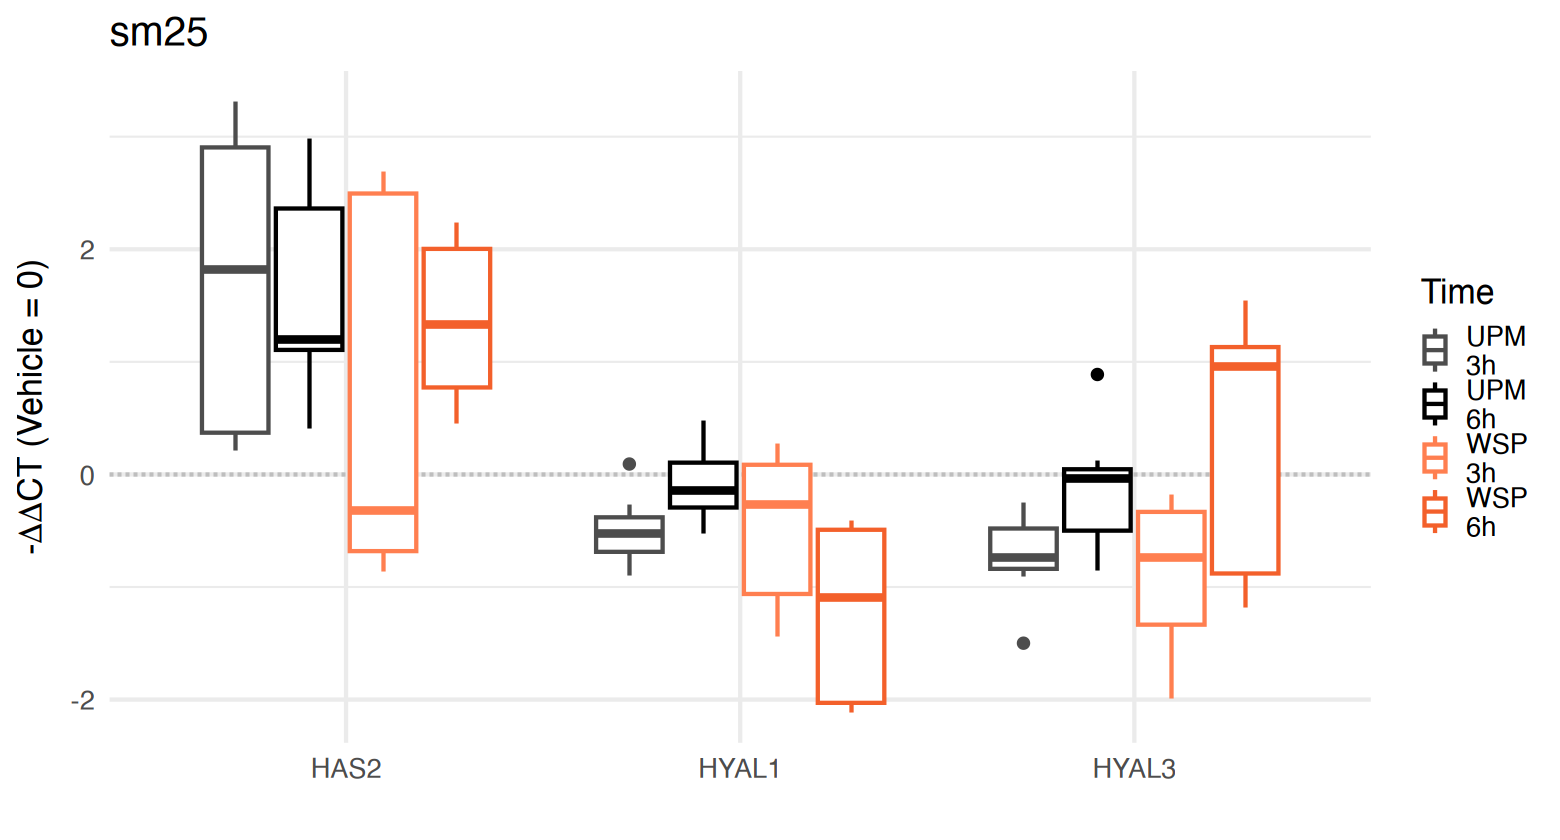

Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."


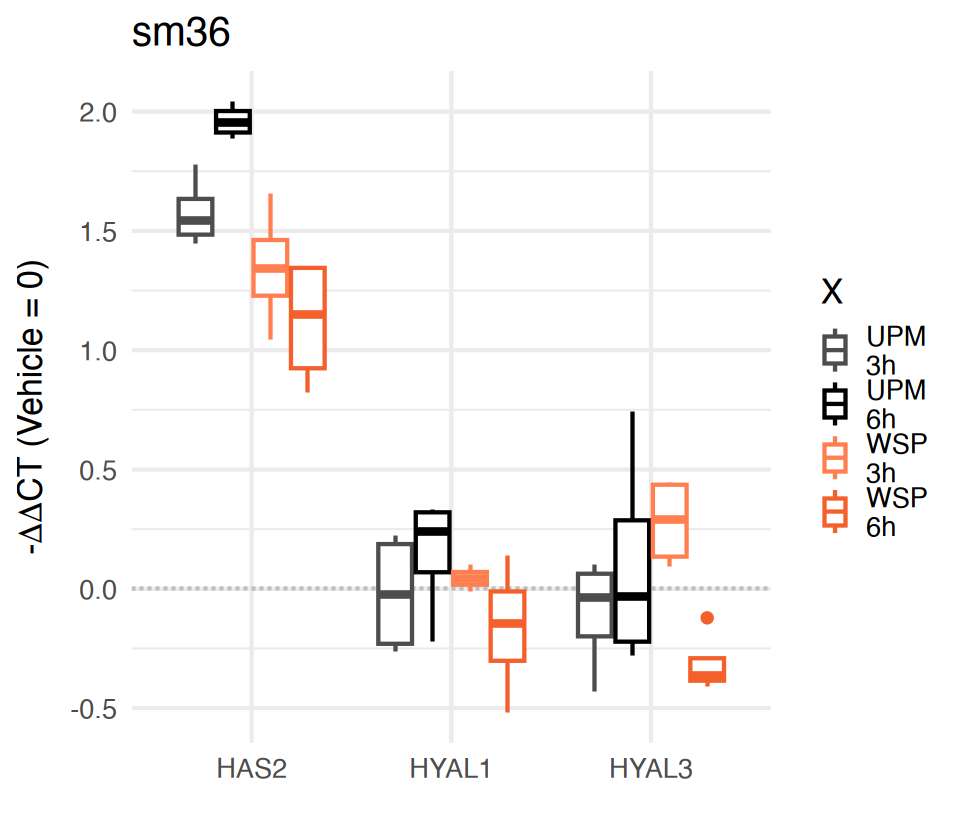

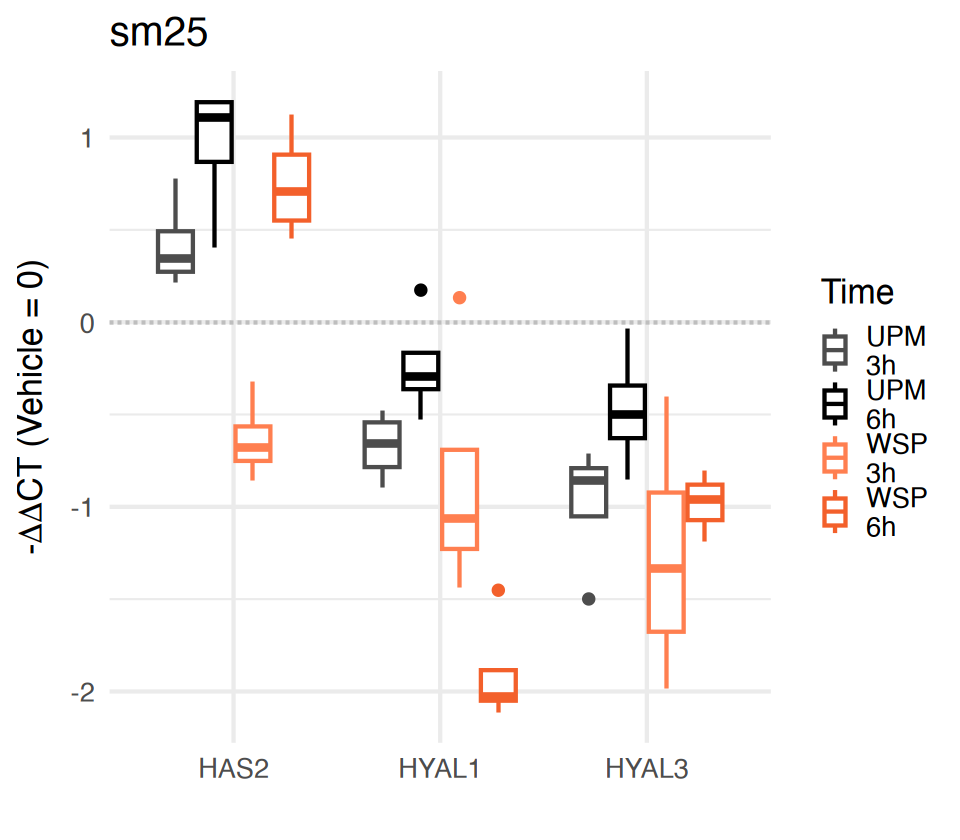

In [112]:
options(repr.plot.width=13)
genes_look = c("HYAL1", "HYAL3", "HAS2")
ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() + facet_wrap(~Date) +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))


ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look,],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  color="Time", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))




#pdf("./sm25_sm26_HASHYAL_2.23.26.pdf", width=8)
options(repr.plot.width=8)
  ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look & qpcr_plot$Date != "1.16.26",],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm36") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh" & qpcr_plot$gene %in% genes_look & qpcr_plot$Date != "1.16.26",],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  ggtitle("sm25") +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(color="Time", x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

#dev.off()


Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


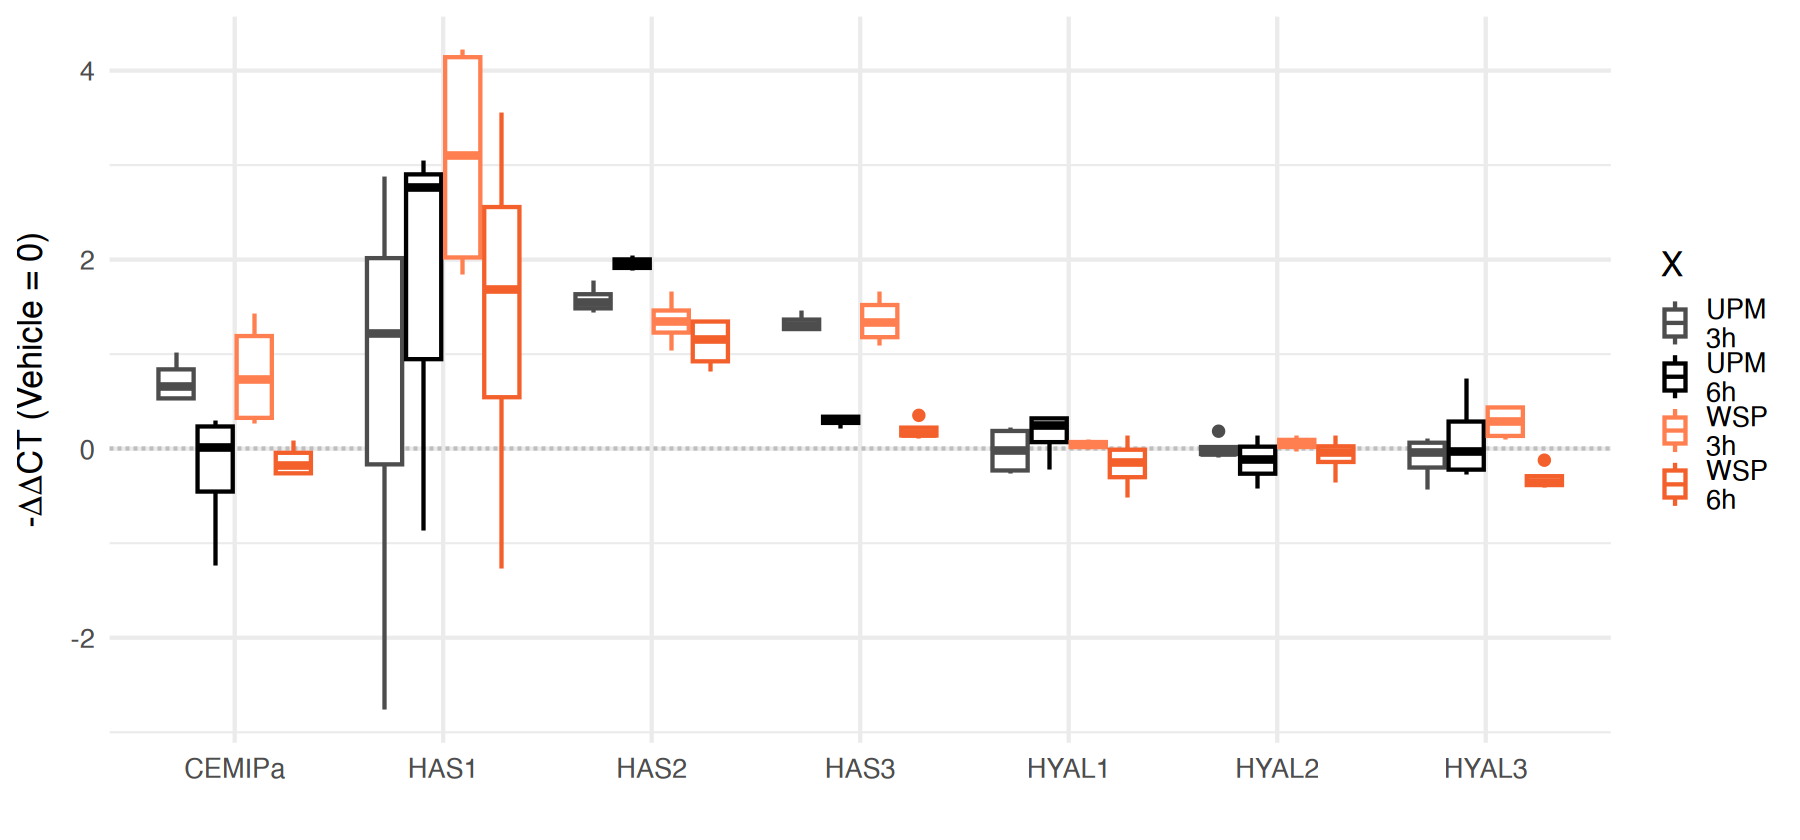

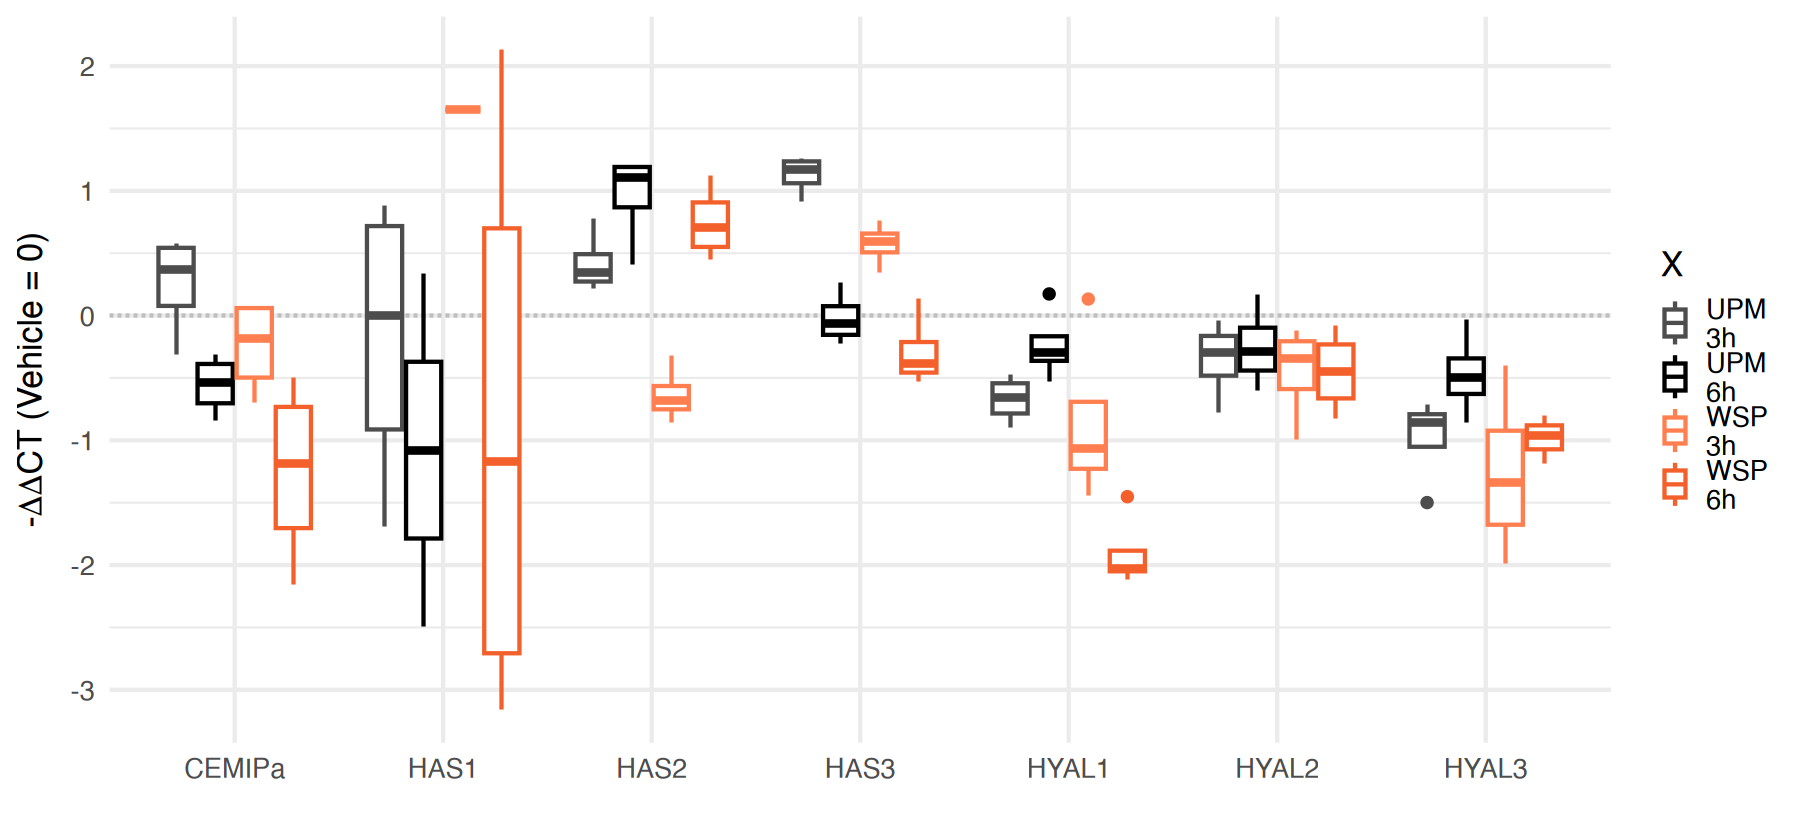

In [45]:
options(repr.plot.width=15)
ggplot(qpcr_plot[qpcr_plot$sm == "sm36" & qpcr_plot$X != "Veh",],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  #geom_jitter(width=0.1, size=2) +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="", y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))

ggplot(qpcr_plot[qpcr_plot$sm == "sm25" & qpcr_plot$X != "Veh",],
aes(x=gene, y=-value, color=X)) + geom_hline(yintercept=0, linetype="dashed", color="grey") + geom_boxplot() +
  #geom_jitter(width=0.1, size=2) +
  theme_minimal(base_size=20) + scale_color_manual(values=color_spec_dict) + labs(x="",  y=expression("-"*Delta*Delta*"CT (Vehicle = 0)"))
  

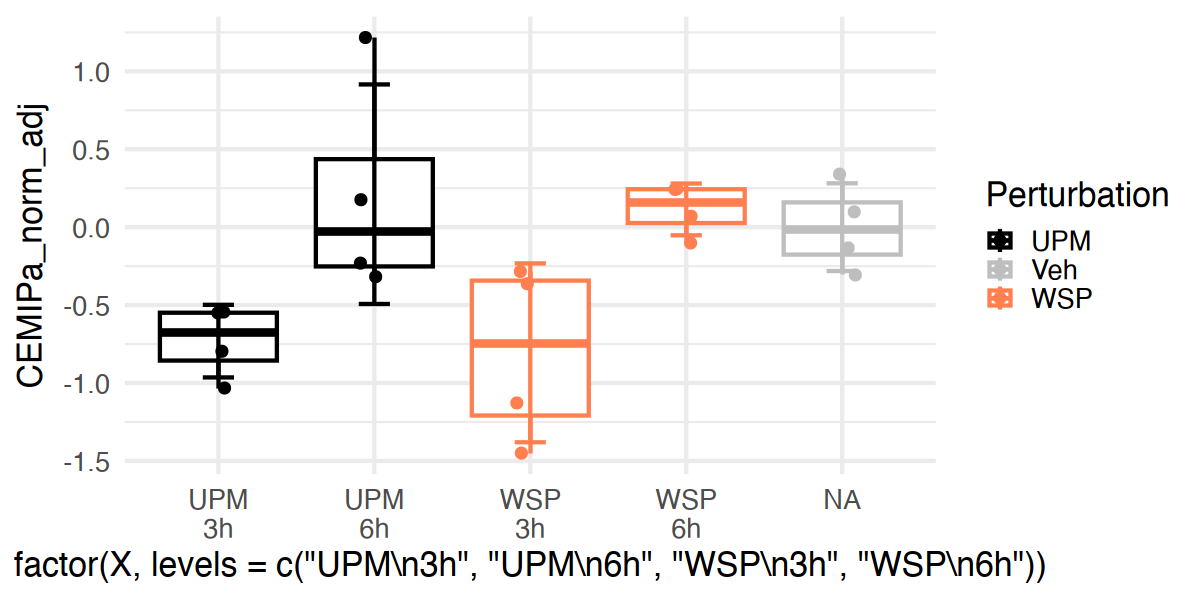

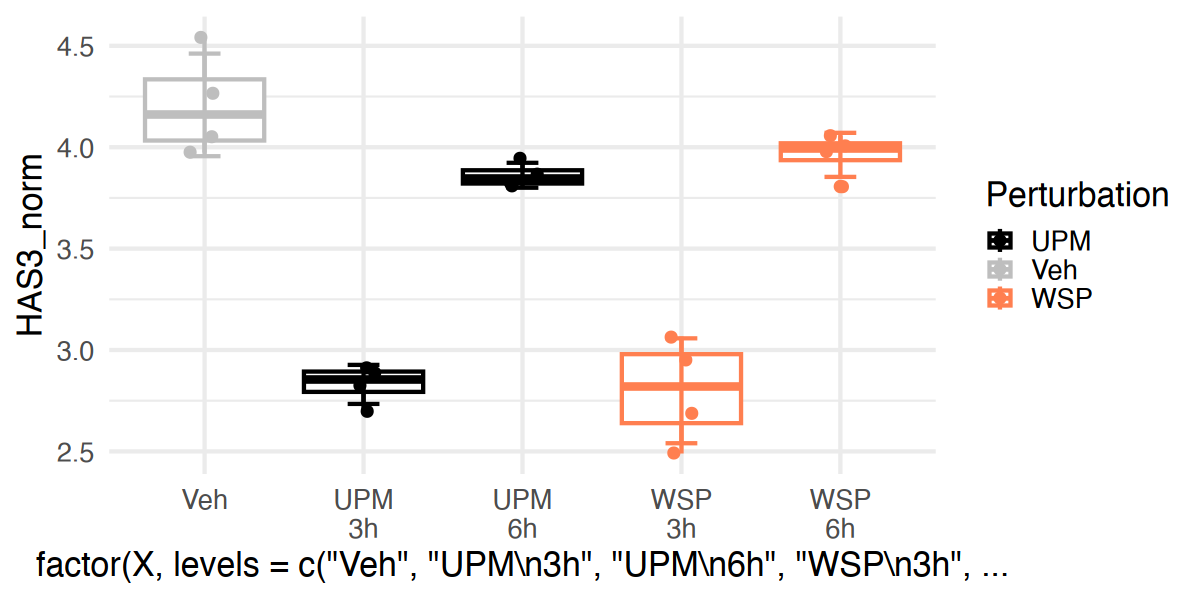

In [168]:
ggplot(qpcr_test[qpcr_test$sm == "sm36",],
aes(x=factor(X, levels=c("UPM\n3h", "UPM\n6h", "WSP\n3h", "WSP\n6h")), y=CEMIPa_norm_adj, color=Perturbation)) + 
# Bar plot of means
  geom_boxplot() +
  # Standard deviation error bars
  stat_summary(
    fun.data = mean_sdl,
    fun.args = list(mult = 1),
    geom = "errorbar",
    width = 0.2
  ) + scale_color_manual(values=color_dict) +
  # Individual data points
  geom_point(position = position_jitter(width = 0.1), size = 2) + theme_minimal(base_size=20) 
ggplot(qpcr[qpcr$sm == "sm36",],
aes(x=factor(X, levels=c("Veh", "UPM\n3h", "UPM\n6h", "WSP\n3h", "WSP\n6h")), y=HAS3_norm, color=Perturbation)) + 
# Bar plot of means
  geom_boxplot() +
  # Standard deviation error bars
  stat_summary(
    fun.data = mean_sdl,
    fun.args = list(mult = 1),
    geom = "errorbar",
    width = 0.2
  ) + scale_color_manual(values=color_dict) +
  # Individual data points
  geom_point(position = position_jitter(width = 0.1), size = 2) + theme_minimal(base_size=20) 